# Penalización por edad y sexo en el mercado laboral argentino
### Trabajo final — Aprendizaje de Máquina (AdM) · CEIA, FIUBA
**Autor:** Ing. Gustavo Varela — Ingeniero Electrónico (FIUBA), MBA

## 1. Introducción y pregunta de investigación

**Planteo.** El objetivo de este trabajo es **entrenar modelos de aprendizaje de
máquina para que aprendan el mercado laboral argentino**: la relación entre las
características observables de una persona (edad, sexo, nivel educativo, región,
año) y sus resultados laborales (estar ocupada, y cuánto gana). Para eso se
descargaron del INDEC los microdatos de la **EPH** (base individual): **1.455.962
registros** con **16 variables** ya decodificadas, que cubren **35 trimestres de
2016 a 2024**. Metodológicamente: un **EDA** ponderado de las brechas, el
**tratamiento de outliers** (winsorización del ingreso), la reserva de un **20% de
los datos como test** y, sobre el 80% restante, el entrenamiento y la comparación de
los **métodos vistos en la cátedra** —regresión lineal y logística, KNN, SVM lineal
y de kernel RBF, árboles de decisión y ensambles (Random Forest, Gradient Boosting,
votación)— con validación cruzada y ajuste de hiperparámetros. Una vez entrenados y
evaluados sobre datos que nunca vieron, los modelos se usan para hacer
**inferencia**: interrogar qué aprendieron sobre el peso de la edad y el sexo
(dependencia parcial, importancia por permutación, SHAP), triangulado con la
descomposición clásica de Oaxaca–Blinder. La distinción entre esos dos usos de un
modelo —**predicción** e **inferencia**— sigue a James et al. (*ISLR*, §2.1.1).

**Pregunta de investigación.** A igual nivel de calificación, ¿en qué medida la
**edad** y el **sexo** se asocian con la probabilidad de permanecer ocupado y con el
ingreso laboral, en particular en la franja cercana a la edad jubilatoria
(mujeres 60 / varones 65)? ¿Y cuánto de lo observado corresponde al **mercado** y
cuánto a factores **institucionales y de oferta** (norma previsional, participación)?

**Hipótesis (dos dimensiones que el análisis se cuida de no mezclar).**

- **H1 — Penalización etaria:** al avanzar la edad —y de forma creciente en los años
  previos a la jubilación *propia* (60 mujeres / 65 varones)— caen la probabilidad de
  estar ocupado y el ingreso relativo, **en ambos sexos**. Comparada a igual distancia
  de la jubilación y entre quienes participan del mercado, la penalización de los
  varones es **igual o mayor** que la de las mujeres.
- **H2 — Brecha por sexo:** la menor tasa de empleo femenina responde ante todo a una
  **brecha de participación** (cuidados, composición del hogar, transferencias y
  regímenes previsionales especiales), más que a una mayor desocupación entre quienes
  buscan trabajo; entre los ocupados subsiste, además, un castigo de **ingresos** por
  sexo que la composición observable no explica.

*La edad exacta en que el deterioro comienza y se acelera se trata como una pregunta
a responder con los datos, no como un umbral fijado de antemano.*

**Relevancia.** Si se verifica una penalización etaria neta —es decir, que persiste
tras controlar por educación, región y año—, el desempleo y la informalidad en las
edades avanzadas no se explicarían únicamente por diferencias de calificación, sino
que existiría un componente de exclusión asociado a la edad y el sexo, con
implicancias para la pobreza en la vejez y para el diseño de políticas de empleo.

**Estrategia metodológica.**
1. **Análisis exploratorio de brechas** (ponderado) por edad y sexo: desocupación,
   la descomposición **empleo = participación × (1 − desocupación)** —para separar
   oferta de demanda—, empleo/inactividad alineados por edad jubilatoria e ingreso
   relativo.
2. **Modelo A — Ingreso (regresión):** estimación del ingreso laboral relativo de
   los ocupados (25–70) y medición del efecto neto de edad y sexo.
3. **Modelo B — Exclusión del empleo (clasificación):** ocupado vs. no-ocupado
   (35–64), con la curva de *partial dependence* de la edad por sexo.
4. **Oaxaca–Blinder:** descomposición de la brecha de ingreso por sexo.
5. **Fairness** (`fairlearn`): auditoría del clasificador por sexo y franja etaria.

Como ampliación se incorporan un árbol de decisión interpretable, SVM con kernel
RBF, el análisis de la **evolución temporal** de las brechas (2016–2024), la
**interpretabilidad mediante SHAP** y la **segmentación por clustering**
(secciones 9–12).

### Mapa metodológico del notebook

El desarrollo sigue el ciclo metodológico de un proyecto de ML (Clase 1):
**pregunta y objetivo** (§1–2) → **datos y preparación** (§3) → **exploración**
(§4) → y, para cada modelo, la secuencia **métrica → baseline → comparación por
validación cruzada → ajuste de hiperparámetros → evaluación única en test**
(§5 ingreso, §6 empleo) → **conclusiones y limitaciones** (§13).

Las demás secciones no compiten con ese hilo: son **validación e interpretación**
de los dos modelos centrales — descomposición Oaxaca–Blinder (§7), auditoría de
fairness (§8), evolución temporal (§9), interpretabilidad SHAP (§10), estructura
no supervisada (§11) y calibración de probabilidades (§12).

## 2. Antecedentes y marco de referencia

El **marco técnico** de este trabajo es el material de la cátedra (*Aprendizaje de
Máquina*, CEIA–FIUBA): metodología y ciclo de vida de un proyecto de ML (Clase 1);
KNN, métricas de evaluación —ROC-AUC— y ajuste de hiperparámetros con validación
cruzada (Clase 2); máquinas de vectores de soporte en clasificación y regresión
(Clase 3); árboles de decisión (Clase 4); métodos de ensamble —bagging, Random
Forest, boosting— (Clase 5); calibración de modelos (Clase 6); y aprendizaje no
supervisado con k-means, suma de cuadrados intra-cluster e índice de silueta
(Clase 7). Conforme a la consigna del trabajo final, el foco está en la
**aplicación, manejo y evaluación de modelos**, con justificación de las
herramientas elegidas.

Sobre el problema de fondo: el estudio de las brechas laborales por **género** y
**edad** en Argentina tiene una tradición consolidada sobre los microdatos de la
EPH (INDEC), la misma fuente empleada aquí, y la descomposición de
**Oaxaca–Blinder** es el enfoque estándar para separar la parte de la brecha
salarial explicada por características observables de la parte no explicada.
En materia de discriminación por edad, Arese (2020) caracteriza el "edadismo"
laboral y previsional como una discriminación generalmente invisible y subraya su
dimensión **previsional** (aceptar un empleo de menor remuneración cerca de la
jubilación deteriora la base de cálculo del haber), mecanismo directamente
relacionado con el que se analiza en este trabajo. Como evidencia de percepción,
una encuesta de Bumeran (2024) reporta que ~61% de los trabajadores sufrió o
presenció discriminación por edad (~86% entre los mayores de 40); contextualiza,
pero no reemplaza, el análisis cuantitativo.

**Aporte del trabajo:** (1) integra en un mismo análisis la brecha de **ingreso** y
la de **empleo/exclusión**; (2) aprovecha la serie 2016–2024 para examinar la
evolución de las brechas; (3) combina las técnicas de la cátedra con econometría
clásica (Oaxaca–Blinder), interpretabilidad (partial dependence, SHAP) y una
auditoría de fairness; (4) discute el mecanismo previsional como factor de la
no-reinserción de los trabajadores de mayor edad.

### Referencias

**Material de la cátedra (fuente principal de las técnicas):**

- Aprendizaje de Máquina, CEIA–FIUBA. Clase 1: *Introducción. Ciclo de vida y metodología.*
- Clase 2: *Clasificador KNN. Métricas de evaluación y curva ROC. Ajuste de hiper-parámetros.*
- Clase 3: *Máquinas de vectores de soporte (clasificación y regresión).*
- Clase 4: *Árboles de decisión. Árboles de clasificación y regresión.*
- Clase 5: *Métodos de ensamble. Bagging, bosques aleatorios, boosting.*
- Clase 6: *Calibración de modelos. Discriminación vs. calibración.*
- Clase 7: *Aprendizaje no supervisado. K-means, suma de cuadrados intra-cluster, índice de la silueta.*

**Bibliografía de la cátedra consultada:**

- James, G., Witten, D., Hastie, T. y Tibshirani, R. *An Introduction to Statistical Learning.* Springer — SVM, árboles y ensambles.
- Hastie, T., Tibshirani, R. y Friedman, J. *The Elements of Statistical Learning.* Springer — boosting e importancia de variables.
- Bruce, P. y Bruce, A. *Practical Statistics for Data Scientists.* O'Reilly — remuestreo y estadística aplicada.

**Técnicas complementarias no cubiertas por el programa (con referencia):**

- Oaxaca, R. (1973). *Male-Female Wage Differentials in Urban Labor Markets.* International Economic Review, 14(3); Blinder, A. (1973). *Wage Discrimination: Reduced Form and Structural Estimates.* Journal of Human Resources, 8(4).
- Lundberg, S. y Lee, S.-I. (2017). *A Unified Approach to Interpreting Model Predictions.* NeurIPS (SHAP).
- Fairlearn — documentación oficial (paridad demográfica, equalized odds).

**Contexto del problema:**

- Arese, C. (2020). *El "edadismo" laboral y previsional.* Revista Derecho de las Minorías, 3. Universidad Católica de Córdoba. DOI: 10.22529/rdm.2020(3)05.
- Bumeran (2024). Encuesta sobre discriminación laboral por edad (difundida por Infobae, 2/6/2024) — evidencia de percepción.
- INDEC. *Encuesta Permanente de Hogares (EPH)* — diseño de registro y factores de expansión de la base individual.


## 3. Datos y preparación

Usamos los **microdatos de la EPH (INDEC)**, base individual, **2016–2024**
(35 trimestres). Los microdatos se descargan con el
paquete `pyeph` y, en una etapa previa de preparación de datos, se decodifican y
limpian hasta obtener la base analítica `data/processed/eph_analitico.parquet`.
Este notebook parte de esa base. El costo se controla con el interruptor **`ML_FIUBA_MODO`** (celda
siguiente): en **`completo`** entrena sobre el **dataset entero** (128 GB de RAM) y
es la corrida cuyas cifras se citan en el texto; en **`rapido`** (por defecto)
submuestrea para iterar en ~1–2 min. El EDA, Oaxaca y las series temporales usan
siempre la población completa. KNN y **SVM con kernel
RBF** (costo de entrenamiento ~O(n²–n³)), que se evalúan sobre un subconjunto
documentado. Además de los requisitos obligatorios, el notebook incluye una
**ampliación**: árbol interpretable, SVM-RBF, evolución temporal de la brecha,
SHAP y segmentación por clustering (secciones 9–12).

In [1]:
# --- Entorno reproducible: ubicarnos en la raíz del proyecto ---
import os, sys, time
from pathlib import Path

_t0 = time.perf_counter()    # cronómetro: mide el tiempo total de ejecución del notebook

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown   # 'lecturas dinámicas': texto generado con los resultados de la corrida

# nbconvert ejecuta con cwd = notebooks/; subimos hasta la raíz del repo
_root = Path.cwd()
while not (_root / "data" / "processed" / "eph_analitico.parquet").exists() and _root != _root.parent:
    _root = _root.parent
os.chdir(_root)
print("Raíz del proyecto:", _root)

SEED = 42
np.random.seed(SEED)

# --- Estilo visual unificado para todas las figuras ---
import matplotlib as mpl
sns.set_theme(style="white", context="notebook", font_scale=1.06)
mpl.rcParams.update({
    "figure.dpi": 115, "savefig.dpi": 150, "savefig.bbox": "tight",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.edgecolor": "#9a9a9a", "axes.linewidth": 1.0,
    "axes.titlesize": 13.5, "axes.titleweight": "semibold", "axes.titlepad": 14,
    "axes.titlelocation": "left",
    "axes.labelsize": 10.5, "axes.labelcolor": "#444",
    "xtick.color": "#666", "ytick.color": "#666",
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "axes.grid": True, "axes.grid.axis": "y",            # sólo guías horizontales, sutiles
    "grid.color": "#e2e2e2", "grid.linewidth": 0.7, "grid.alpha": 0.9,
    "legend.frameon": False, "font.family": "DejaVu Sans",
    "lines.solid_capstyle": "round",
})
VAR, MUJ = "#2C6E9E", "#C0476C"          # azul (varón) / frambuesa (mujer), consistentes
ACEN, GRIS = "#E8A100", "#8a8a8a"        # acento (quiebres) y gris (anotaciones)

def estilo_serie(ax, titulo="", xlab="Edad", ylab=""):
    # Aplica detalles finos comunes a un gráfico de series por edad
    ax.set_title(titulo); ax.set_xlabel(xlab); ax.set_ylabel(ylab)
    ax.margins(x=0.01)
    return ax

def fin_de_linea(ax, x, y, texto, color):
    # Etiqueta directa al final de la línea (más legible que una leyenda)
    ax.annotate(texto, (x, y), xytext=(7, 0), textcoords="offset points",
                color=color, fontweight="bold", fontsize=10, va="center",
                annotation_clip=False)

def marca_quiebre(ax, x, y, color, texto, dx=12, dy=28):
    # Señala un punto de quiebre: marcador + texto conectado con una línea fina
    ax.plot([x], [y], "o", color=color, ms=7.5, mec="white", mew=1.4, zorder=6)
    ax.annotate(texto, (x, y), xytext=(dx, dy), textcoords="offset points",
                fontsize=9, color=color, fontweight="bold", ha="left",
                arrowprops=dict(arrowstyle="-", color=color, lw=0.9,
                                shrinkA=0, shrinkB=5, alpha=.75))

FIG = Path("reports/figures"); FIG.mkdir(parents=True, exist_ok=True)
PROC = Path("data/processed")
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

Raíz del proyecto: /Users/gv/projects/ceia_add/ML FIUBA


### Modo de ejecución — `ML_FIUBA_MODO` (rápido vs. completo)

Un **único interruptor** escala todo el costo del notebook **sin cambiar su
estructura ni sus conclusiones**, sólo el tiempo de cómputo:

- **`rapido`** (valor por defecto): submuestrea para reejecutar en ~1–2 min e
  iterar mientras se estudia o se prepara la defensa.
- **`completo`**: usa el dataset entero; es la corrida final cuyas cifras se citan
  en el texto (~15–20 min).

Se controla con la variable de entorno `ML_FIUBA_MODO`:

```bash
# iterar / estudiar (rápido, por defecto)
uv run jupyter nbconvert --to notebook --execute --inplace notebooks/entrega.ipynb

# corrida final para la entrega (números definitivos)
ML_FIUBA_MODO=completo uv run jupyter nbconvert --to notebook --execute --inplace notebooks/entrega.ipynb
```

Todos los parámetros costosos salen del diccionario `P` de la celda siguiente: no
hay números mágicos sueltos en el resto del notebook.

In [2]:
# --- Interruptor de costo: ML_FIUBA_MODO = 'rapido' (default) | 'completo' ---
MODO = os.environ.get("ML_FIUBA_MODO", "rapido").strip().lower()
if MODO not in ("rapido", "completo"):
    print(f"[aviso] ML_FIUBA_MODO='{MODO}' no reconocido; uso 'rapido'."); MODO = "rapido"

PARAMS = {
    # rapido = para estudiar/iterar ; completo = corrida final de entrega
    "rapido":   dict(n_modelo=15_000, sub_svm_rbf=3_000,  n_shap=1_000,
                     perm_repeats=3,  kmeans_ninit=3,  grid_full=False, boot_reps=200),
    "completo": dict(n_modelo=None,   sub_svm_rbf=12_000, n_shap=5_000,
                     perm_repeats=10, kmeans_ninit=10, grid_full=True,  boot_reps=1000),
}
P = PARAMS[MODO]
print(f"Modo de ejecución: {MODO.upper()}")
for k, v in P.items():
    print(f"  {k:14}: {'dataset completo' if v is None else v}")

Modo de ejecución: COMPLETO
  n_modelo      : dataset completo
  sub_svm_rbf   : 12000
  n_shap        : 5000
  perm_repeats  : 10
  kmeans_ninit  : 10
  grid_full     : True
  boot_reps     : 1000


> 🧭 Cargo la base analítica ya decodificada y limpia (`eph_analitico.parquet`), que preparé aguas arriba a partir de los microdatos crudos de la EPH (descarga con `pyeph`, traducción de códigos y control de calidad). Un *parquet* es un formato columnar comprimido: ocupa poco y se lee rápido. Separo deliberadamente la *preparación* (descarga, traducción de los códigos numéricos de la EPH a etiquetas legibles, control de calidad) del *análisis*. Esta separación es una buena práctica reconocida de ingeniería de datos: garantiza reproducibilidad (parto siempre del mismo insumo estable) y mantiene el notebook liviano en lugar de releer ~1,8 M de registros crudos en cada corrida.
>
> Si mezclara limpieza y análisis en el mismo flujo, el trabajo sería frágil y difícil de auditar: un cambio en la decodificación podría alterar en silencio todos los resultados posteriores, sin que quede traza de la causa.

In [3]:
# --- Base analítica de la EPH (ya decodificada y limpia) ---
df = pd.read_parquet(PROC / "eph_analitico.parquet")
print(f"Registros: {len(df):,}   columnas: {df.shape[1]}")
print(f"Años: {df['anio'].min()}–{df['anio'].max()}   "
      f"trimestres distintos: {df.groupby(['anio','trimestre']).ngroups}")
print(f"Memoria en RAM: {df.memory_usage(deep=True).sum()/1e6:,.0f} MB")
df.head(3)

Registros: 1,455,962   columnas: 16
Años: 2016–2024   trimestres distintos: 35


Memoria en RAM: 416 MB


,anio,trimestre,REGION,AGLOMERADO,sexo,edad,nivel_ed,cond,CAT_OCUP,PP07H,P21,P47T,PONDERA,PONDIIO,PONDII,ESTADO
0,2016,2,1,33,Varón,32,Superior comp.,Ocupado,3.000,1.000,"20,000.000","20,000.000",892,1063,1163,1
1,2016,2,1,33,Mujer,34,Superior inc.,Ocupado,3.000,1.000,"15,600.000","15,600.000",892,1118,1164,1
2,2016,2,1,33,Varón,17,Secundario inc.,Inactivo,0.000,NaN,0.000,0.000,892,892,892,3


In [4]:
# --- Diccionario breve de variables (códigos EPH y su decodificación) ---
diccionario = pd.DataFrame([
    ("CH04 → sexo",      "Sexo (1 Varón, 2 Mujer)"),
    ("CH06 → edad",      "Edad en años"),
    ("ESTADO → cond",    "Condición de actividad (1 Ocupado, 2 Desocupado, 3 Inactivo, 4 Menor)"),
    ("NIVEL_ED → nivel_ed", "Nivel educativo (primario/secundario/superior, inc./comp.)"),
    ("REGION",           "Región del país (GBA, NOA, NEA, Cuyo, Pampeana, Patagonia)"),
    ("CAT_OCUP",         "Categoría ocupacional (sólo ocupados)"),
    ("PP07H",            "Descuento jubilatorio (sólo ocupados)"),
    ("P21",              "Ingreso de la ocupación principal"),
    ("P47T",             "Ingreso total individual"),
    ("PONDERA",          "Ponderador poblacional (para tasas)"),
    ("PONDIIO / PONDII", "Ponderadores de ingreso (P21 / P47T)"),
], columns=["Variable", "Descripción"])
diccionario

,Variable,Descripción
0,CH04 → sexo,"Sexo (1 Varón, 2 Mujer)"
1,CH06 → edad,Edad en años
2,ESTADO → cond,"Condición de actividad (1 Ocupado, 2 Desocupad..."
3,NIVEL_ED → nivel_ed,"Nivel educativo (primario/secundario/superior,..."
4,REGION,"Región del país (GBA, NOA, NEA, Cuyo, Pampeana..."
5,CAT_OCUP,Categoría ocupacional (sólo ocupados)
6,PP07H,Descuento jubilatorio (sólo ocupados)
7,P21,Ingreso de la ocupación principal
8,P47T,Ingreso total individual
9,PONDERA,Ponderador poblacional (para tasas)


### Decisiones metodológicas (para evitar inferencias espurias)

- **Uso sistemático de ponderadores.** Las tasas se calculan con `PONDERA`
  (ponderador poblacional) y los ingresos con `PONDIIO`. De lo contrario, los
  aglomerados de mayor tamaño quedarían sub-representados.
- **Tratamiento de la inflación (elevada en 2016–2024).** No se comparan valores
  nominales entre trimestres. Se trabaja con el **ingreso relativo**: `P21`
  dividido por la **mediana de los ocupados del mismo trimestre**. De este modo,
  `1.0` corresponde a la mediana trimestral y los valores resultan comparables a lo
  largo de los nueve años.
- **Limitación de la tasa de desocupación.** En las edades avanzadas, una parte de
  la población no se registra como "desocupada" sino que transita hacia la
  **inactividad** (efecto del *trabajador desalentado*). Por ello se reportan
  también las tasas de empleo e inactividad.
- **Ausencia de fuga de información.** En el clasificador de empleo no se emplean
  `CAT_OCUP` ni `PP07H`, que sólo existen para personas ocupadas; su uso
  introduciría *data leakage*. Las variables admisibles son edad, sexo, nivel
  educativo, región y año.
- **Separación de dimensiones.** La brecha de empleo por sexo se descompone en
  **participación** vs. **desocupación** (oferta vs. demanda) y las comparaciones
  etarias se **alinean por la edad jubilatoria de cada sexo** (60/65). Sin estas dos
  precauciones se atribuiría al mercado lo que en realidad explican la norma
  previsional o las decisiones de oferta del hogar.

## 4. EDA de brechas por edad y sexo

Previo al modelado se examinan los datos (ponderados) desde tres perspectivas
complementarias: desocupación, salida del mercado (empleo/inactividad) e ingreso.

### 4.1 Desocupación por edad y sexo — *alcances y limitaciones*

> 🧭 Calculo la **tasa de desocupación** (desocupados sobre población económicamente activa) por edad y sexo, **ponderando** cada persona por `PONDERA` —el factor de expansión que indica a cuántos individuos de la población representa cada encuestado—. Empiezo por la métrica más conocida para mostrar, justamente, que **no alcanza**. La grafico dos veces: por edad y **superpuesta en años hasta la jubilación propia** (t=0 = 60 mujeres / 65 varones): como las edades jubilatorias difieren en cinco años, ese corrimiento es el que permite comparar a los dos sexos *peras con peras*. Pondero porque la EPH es una muestra con probabilidades de selección desiguales: sólo expandiendo por `PONDERA` los porcentajes representan a la población y no a la muestra.
>
> Sin ponderar, sobre/sub-representaría aglomerados y grupos según cómo se muestrearon, y obtendría tasas sesgadas que no describen al país.

findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


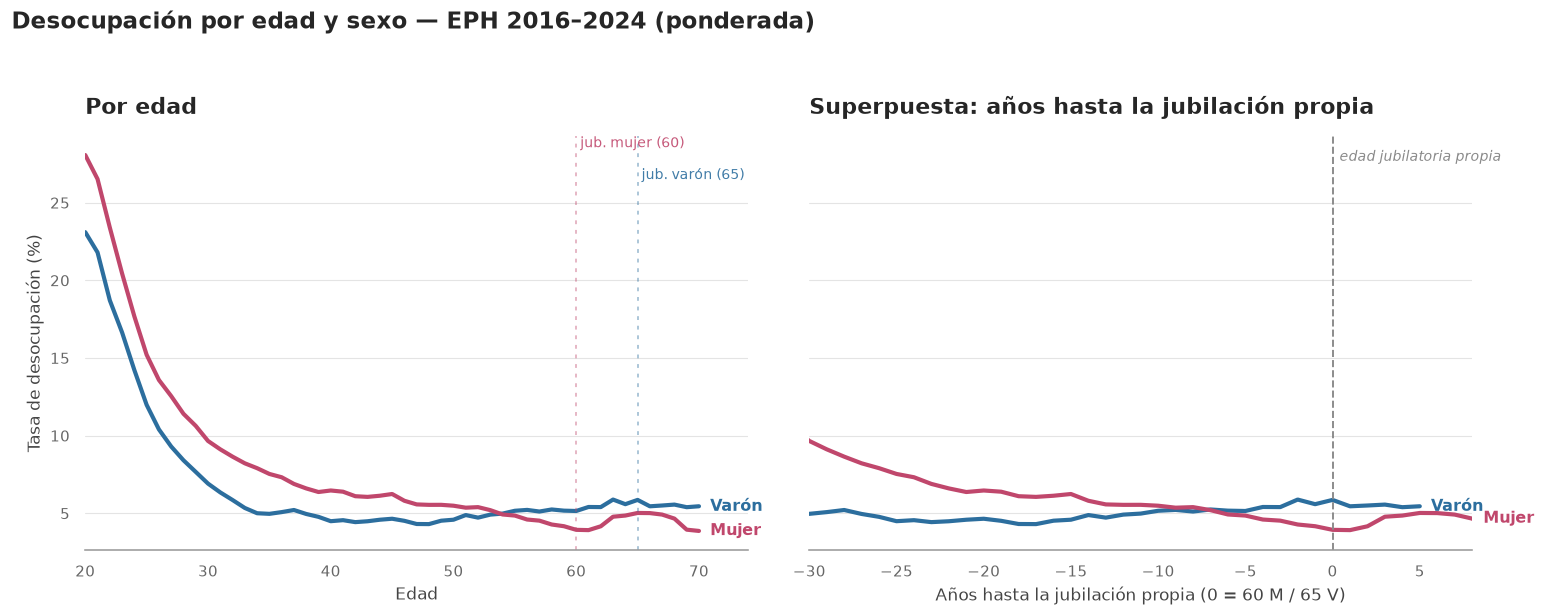

In [5]:
def tasa_desocupacion(d, by="edad"):
    # Desocupados / PEA, ponderado por PONDERA
    pea = d[d["ESTADO"].isin([1, 2])].copy()
    pea["w_deso"] = pea["PONDERA"].where(pea["ESTADO"] == 2, 0)
    return pea.groupby(by, observed=True).apply(
        lambda x: 100 * x["w_deso"].sum() / x["PONDERA"].sum(), include_groups=False)

RET = {"Varón": 65, "Mujer": 60}   # edad jubilatoria legal por sexo
edades = range(20, 71)
fig, ax = plt.subplots(1, 2, figsize=(13.5, 5.2), sharey=True)
for sx, col in [("Varón", VAR), ("Mujer", MUJ)]:
    serie = (tasa_desocupacion(df[df.sexo == sx]).reindex(edades)
             .rolling(3, center=True, min_periods=1).mean())
    ax[0].plot(list(edades), serie.values, color=col, lw=2.6)
    fin_de_linea(ax[0], 70, serie.iloc[-1], sx, col)
    # panel derecho: la MISMA curva con el eje corrido a años hasta la jubilación propia
    ts = [e - RET[sx] for e in edades]
    ax[1].plot(ts, serie.values, color=col, lw=2.6)
    t_lab = 5 if sx == "Varón" else 8
    fin_de_linea(ax[1], t_lab, serie.values[list(edades).index(RET[sx] + t_lab)], sx, col)
for x, col in [(60, MUJ), (65, VAR)]:
    ax[0].axvline(x, ls=(0, (2, 3)), c=col, alpha=.4, lw=1.2)
ax[0].text(60, ax[0].get_ylim()[1], " jub. mujer (60)", color=MUJ, fontsize=8.5, va="top", alpha=.9)
ax[0].text(65, ax[0].get_ylim()[1] * .93, " jub. varón (65)", color=VAR, fontsize=8.5, va="top", alpha=.9)
ax[1].axvline(0, ls="--", c=GRIS, lw=1.2)
ax[1].text(0.4, ax[1].get_ylim()[1] * .97, "edad jubilatoria propia", color=GRIS,
           fontsize=8.5, va="top", style="italic")
estilo_serie(ax[0], "Por edad", "Edad", "Tasa de desocupación (%)")
estilo_serie(ax[1], "Superpuesta: años hasta la jubilación propia",
             "Años hasta la jubilación propia (0 = 60 M / 65 V)", "")
ax[0].set_xlim(20, 74); ax[1].set_xlim(-30, 8)
fig.suptitle("Desocupación por edad y sexo — EPH 2016–2024 (ponderada)",
             x=0.005, ha="left", y=1.03, fontsize=14.5, fontweight="semibold")
plt.tight_layout(); plt.savefig(FIG / "desocupacion_edad_sexo.png"); plt.show()

La tasa de desocupación de las edades avanzadas **no se incrementa** e incluso
desciende cerca de la jubilación. Sería incorrecto interpretarlo como una menor
dificultad de inserción: una parte de esta población **deja de buscar empleo** y
abandona la población económicamente activa (la salida efectiva se dimensiona en
4.2). El gráfico deja además una segunda pista, fácil de pasar por alto: las curvas
por sexo **se cruzan en torno a los 55 años** — de ahí en adelante la desocupación
más alta es la **masculina**. La descomposición siguiente cuantifica ese cruce.

#### La brecha de empleo por sexo, descompuesta: participación vs. desocupación

> 🧭 Descompongo la tasa de empleo en sus dos factores: **empleo = participación × (1 − desocupación)**. La participación (qué parte de la población se ofrece al mercado) concentra los determinantes de **oferta** —cuidados, composición del hogar, transferencias como la AUH, regímenes previsionales especiales—; la desocupación **entre quienes participan** es la señal más cercana a la **demanda** (cómo le va a quien efectivamente busca o tiene trabajo). Calculo ambas por franja etaria y sexo, ponderando por `PONDERA`. Esta separación es la que impide leer toda la brecha de empleo por sexo como discriminación del mercado.
>
> Si no descompusiera, ~20 puntos de brecha de empleo se leerían como exclusión de demanda cuando pueden ser, en parte, decisiones u obligaciones del hogar; y me perdería el dato clave de que, entre los activos cercanos a la jubilación, la desocupación **masculina** pasa a ser la más alta.

In [6]:
# --- Descomposición empleo = participación × (1 − desocupación), por franja y sexo ---
FRANJAS = [(25, 34), (35, 44), (45, 54), (55, 59), (60, 64)]
_base = df.assign(activo=df["ESTADO"].isin([1, 2]))
def _tasa(d, flag):
    # % ponderado (PONDERA) del grupo que cumple `flag`
    return 100 * d.loc[d[flag], "PONDERA"].sum() / d["PONDERA"].sum()
filas = []
for lo, hi in FRANJAS:
    fila = {"franja": f"{lo}-{hi}"}
    for sx in ["Varón", "Mujer"]:
        g = _base[(_base.sexo == sx) & _base.edad.between(lo, hi)]
        pea = g[g.activo].assign(deso=lambda x: x["ESTADO"] == 2)
        fila[f"part_{sx}"] = _tasa(g, "activo")     # participación (tasa de actividad)
        fila[f"deso_{sx}"] = _tasa(pea, "deso")     # desocupación ENTRE activos
    filas.append(fila)
PD = pd.DataFrame(filas).set_index("franja")
PD["brecha_part"] = PD["part_Mujer"] - PD["part_Varón"]   # negativa: mujer participa menos
PD["brecha_deso"] = PD["deso_Mujer"] - PD["deso_Varón"]   # negativa: deso. masculina mayor
print("Participación (%) y desocupación entre activos (%), por franja y sexo:")
print(PD.round(1).to_string())

Participación (%) y desocupación entre activos (%), por franja y sexo:
        part_Varón  deso_Varón  part_Mujer  deso_Mujer  brecha_part  brecha_deso
franja                                                                          
25-34       90.700       7.700      68.600      10.600      -22.000        2.900
35-44       94.800       4.700      75.400       6.600      -19.500        1.800
45-54       92.400       4.600      72.400       5.600      -20.100        0.900
55-59       85.300       5.200      61.000       4.500      -24.300       -0.700
60-64       75.400       5.500      37.200       4.300      -38.200       -1.300


In [7]:
# --- Lectura dinámica: participación vs. desocupación, cifras de esta corrida ---
from IPython.display import Markdown
_pgap = -PD.loc["35-44":"45-54", "brecha_part"].mean()
_cruce = next((f for f in PD.index if PD.loc[f, "brecha_deso"] < 0), "55-59")
_dv55, _dm55 = PD.loc["55-59", "deso_Varón"], PD.loc["55-59", "deso_Mujer"]
_dv60, _dm60 = PD.loc["60-64", "deso_Varón"], PD.loc["60-64", "deso_Mujer"]
_dj = PD.loc["25-34", "brecha_deso"]
Markdown(f"""**Lectura — dónde vive realmente la brecha por sexo.** Tres hechos:

1. **La brecha de empleo por sexo es, ante todo, una brecha de PARTICIPACIÓN.** En las
   franjas centrales (35–54) las mujeres participan **~{_pgap:.0f} puntos menos** que los
   varones. En ese margen operan los determinantes de **oferta** —cuidados, composición
   del hogar, transferencias (p. ej. la AUH), regímenes especiales— que la EPH no
   registra: la brecha **mezcla** elección/inducción del hogar con desaliento, y con un
   corte transversal no es separable de la demanda.
2. **Entre quienes participan, la historia cambia con la edad.** De jóvenes la
   desocupación femenina es algo mayor (+{_dj:.1f} pts a los 25–34); pero la brecha se
   achica con la edad y **se invierte en la franja {_cruce}**: a los 55–59 la desocupación
   masculina ({_dv55:.1f}%) supera a la femenina ({_dm55:.1f}%), y a los 60–64 la diferencia se
   amplía ({_dv60:.1f}% vs. {_dm60:.1f}%). **Cerca de la jubilación, a los varones que siguen en el
   mercado les va peor** — consistente con H1: la penalización etaria de demanda no es
   menor en los varones.
3. **Caveat de selección (en ambas direcciones).** Quienes participan se autoseleccionan
   (las mujeres activas de 55+ pueden ser un grupo particularmente apegado al mercado) y
   el *trabajador desalentado* cae en inactividad, de modo que algo de demanda puede
   esconderse en la brecha de participación. Por eso estas tasas se leen como **señal**,
   no como medida limpia de discriminación.""")

**Lectura — dónde vive realmente la brecha por sexo.** Tres hechos:

1. **La brecha de empleo por sexo es, ante todo, una brecha de PARTICIPACIÓN.** En las
   franjas centrales (35–54) las mujeres participan **~20 puntos menos** que los
   varones. En ese margen operan los determinantes de **oferta** —cuidados, composición
   del hogar, transferencias (p. ej. la AUH), regímenes especiales— que la EPH no
   registra: la brecha **mezcla** elección/inducción del hogar con desaliento, y con un
   corte transversal no es separable de la demanda.
2. **Entre quienes participan, la historia cambia con la edad.** De jóvenes la
   desocupación femenina es algo mayor (+2.9 pts a los 25–34); pero la brecha se
   achica con la edad y **se invierte en la franja 55-59**: a los 55–59 la desocupación
   masculina (5.2%) supera a la femenina (4.5%), y a los 60–64 la diferencia se
   amplía (5.5% vs. 4.3%). **Cerca de la jubilación, a los varones que siguen en el
   mercado les va peor** — consistente con H1: la penalización etaria de demanda no es
   menor en los varones.
3. **Caveat de selección (en ambas direcciones).** Quienes participan se autoseleccionan
   (las mujeres activas de 55+ pueden ser un grupo particularmente apegado al mercado) y
   el *trabajador desalentado* cae en inactividad, de modo que algo de demanda puede
   esconderse en la brecha de participación. Por eso estas tasas se leen como **señal**,
   no como medida limpia de discriminación.

### 4.2 Empleo e inactividad — *dónde empieza realmente el descenso*

> 🧭 Calculo la **tasa de empleo** (ocupados sobre el total del grupo) y la **tasa de inactividad** (no trabaja ni busca) por edad y sexo. Antes de describir 'a qué edad cae el empleo', **estimo el punto de quiebre directamente de los datos**: el **pico**, el **inicio del descenso** (primera edad con caída sostenida) y la **aceleración** (quiebre de un ajuste de dos rectas a la curva). Miro empleo e inactividad porque la desocupación sólo cuenta a quienes **buscan**; a edades altas mucha gente pasa a 'inactiva' (trabajador desalentado) y esa salida real sólo la capta la tasa de empleo. Y **estimo el umbral en vez de fijarlo a priori** para que la edad de quiebre sea un **resultado**, no un supuesto: dejo que los datos digan dónde y para quién empieza la penalización.
>
> Fijar un umbral 'a ojo' (p. ej. 58) arrastra un **sesgo de anclaje**: podría ver una ruptura donde no la hay y, peor, perder que el descenso empieza antes y a edades distintas según el sexo.

In [8]:
def tasa_estado(d, estados, by="edad"):
    # % de la población del grupo que está en `estados`, ponderado por PONDERA
    d = d.copy()
    d["w"] = d["PONDERA"].where(d["ESTADO"].isin(estados), 0)
    return d.groupby(by, observed=True).apply(
        lambda x: 100 * x["w"].sum() / x["PONDERA"].sum(), include_groups=False)

def curva_empleo(sx):
    # tasa de empleo por edad (35-70), suavizada con media móvil de 3 años
    return (tasa_estado(df[df.sexo == sx], [1]).reindex(range(35, 71))
            .rolling(3, center=True, min_periods=1).mean())

def quiebre_dos_rectas(s, lo=45, hi=66):
    # ajusta DOS rectas con quiebre en cada edad candidata y elige el de menor error:
    # estima la 'edad de aceleración' del descenso de empleo sin fijarla a mano
    a = np.arange(lo, hi + 1); y = s.loc[lo:hi].values
    err = lambda bk: sum(np.sum((y[m] - np.polyval(np.polyfit(a[m], y[m], 1), a[m]))**2)
                         for m in (a <= bk, a >= bk))
    return min(range(lo + 3, hi - 2), key=err)

RET = {"Varón": 65, "Mujer": 60}   # edad jubilatoria legal por sexo (se usa en las marcas)

# Puntos de quiebre ESTIMADOS (no fijados a priori), por sexo
BK = {}
for sx in ["Varón", "Mujer"]:
    s = curva_empleo(sx); slope = s.diff()                  # pendiente en puntos/año
    pico  = int(s.idxmax())
    onset = next(a for a in range(42, 66) if slope.loc[a:a+2].mean() < -0.8)  # descenso sostenido
    knee  = int(quiebre_dos_rectas(s))                      # aceleración (2 rectas)
    BK[sx] = {"pico": pico, "inicio_descenso": int(onset), "aceleracion": knee}
print("Puntos de quiebre de la curva de empleo — ESTIMADOS de los datos:")
print(pd.DataFrame(BK).T.to_string())

Puntos de quiebre de la curva de empleo — ESTIMADOS de los datos:
       pico  inicio_descenso  aceleracion
Varón    40               51           62
Mujer    42               49           56


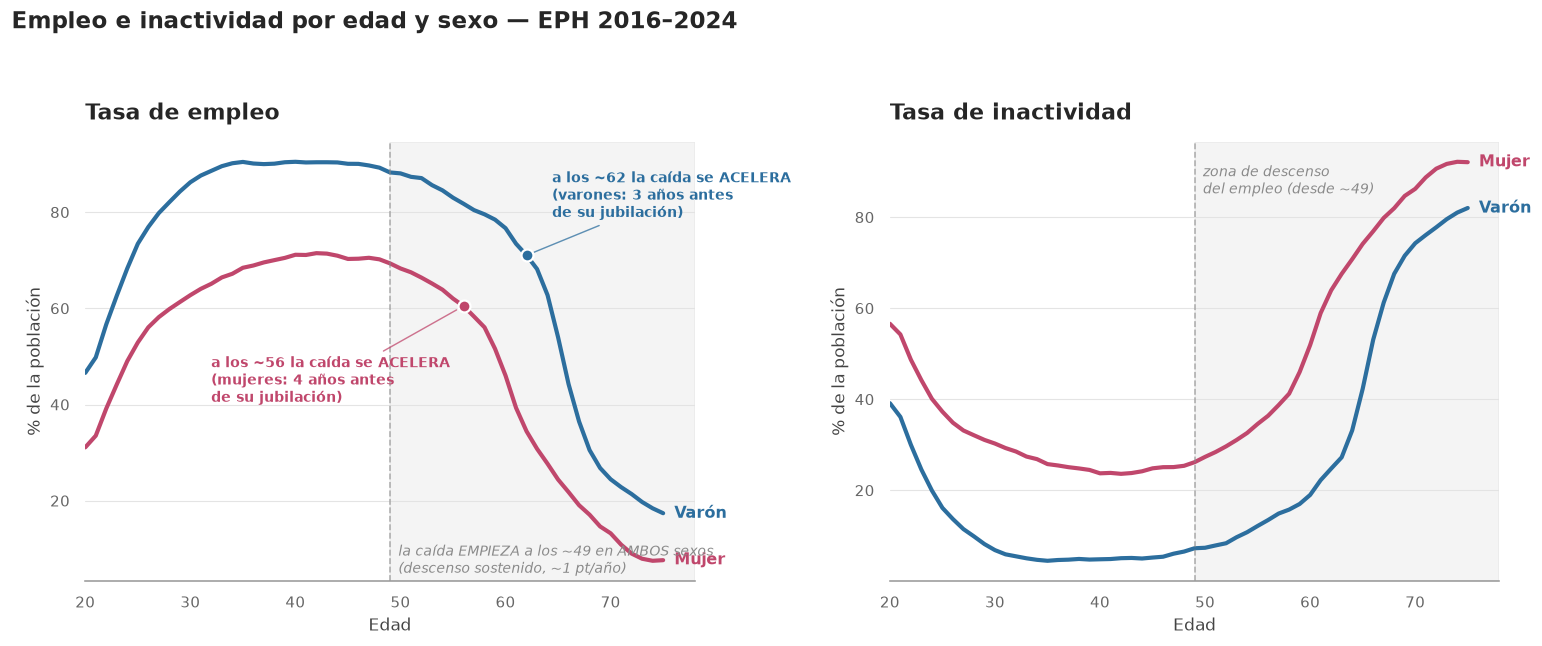

Tasa de empleo por franja y sexo (%)
sexo    Mujer  Varón
franja              
25-49  66.600 87.400
50-59  62.600 83.800
60-64  35.600 71.200
65-75  14.500 29.800


In [9]:
edades = range(20, 76)
curvas = {}
fig, ax = plt.subplots(1, 2, figsize=(13.5, 5.4), sharex=True)
for sx, col in [("Varón", VAR), ("Mujer", MUJ)]:
    sub = df[df.sexo == sx]
    emp = tasa_estado(sub, [1]).reindex(edades).rolling(3, center=True, min_periods=1).mean()
    ina = tasa_estado(sub, [3]).reindex(edades).rolling(3, center=True, min_periods=1).mean()
    curvas[sx] = emp
    ax[0].plot(list(edades), emp.values, color=col, lw=2.6)
    ax[1].plot(list(edades), ina.values, color=col, lw=2.6)
    fin_de_linea(ax[0], 75, emp.iloc[-1], sx, col)
    fin_de_linea(ax[1], 75, ina.iloc[-1], sx, col)
    # punto donde la caída del empleo SE ACELERA (estimado en la celda anterior)
    k = BK[sx]["aceleracion"]
    marca_quiebre(ax[0], k, emp[k], col,
                  f"a los ~{k} la caída se ACELERA\n({'varones' if sx == 'Varón' else 'mujeres'}: {RET[sx] - k} años antes\nde su jubilación)",
                  dx=(16 if sx == "Varón" else -158), dy=(24 if sx == "Varón" else -60))
# banda gris: descenso sostenido del empleo desde el inicio estimado
onset_min = min(BK[s]["inicio_descenso"] for s in BK)
for a in ax:
    a.axvspan(onset_min, 78, color=GRIS, alpha=.09, zorder=0)
    a.axvline(onset_min, ls="--", c=GRIS, lw=1, alpha=.65)
    a.set_xlabel("Edad"); a.set_xlim(20, 78)
ax[0].text(onset_min + 0.8, 5, f"la caída EMPIEZA a los ~{onset_min} en AMBOS sexos\n(descenso sostenido, ~1 pt/año)",
           color=GRIS, fontsize=8.8, style="italic")
ax[1].text(onset_min + 0.8, ax[1].get_ylim()[1] * .95, f"zona de descenso\ndel empleo (desde ~{onset_min})",
           color=GRIS, fontsize=8.8, style="italic", va="top")
estilo_serie(ax[0], "Tasa de empleo", "Edad", "% de la población")
estilo_serie(ax[1], "Tasa de inactividad", "Edad", "% de la población")
fig.suptitle("Empleo e inactividad por edad y sexo — EPH 2016–2024",
             x=0.005, ha="left", y=1.04, fontsize=14.5, fontweight="semibold")
plt.tight_layout(); plt.savefig(FIG / "empleo_inactividad.png"); plt.show()

# Tabla por franja — cortes motivados por los quiebres estimados (no por un "58" a priori)
bins = [25, 50, 60, 65, 76]; labels = ["25-49", "50-59", "60-64", "65-75"]
g = df[df.edad.between(25, 75)].copy()
g["franja"] = pd.cut(g.edad, bins=bins, labels=labels, right=False)
emp_tab = g.groupby(["franja", "sexo"], observed=True).apply(
    lambda x: 100 * x.loc[x.ESTADO == 1, "PONDERA"].sum() / x["PONDERA"].sum(),
    include_groups=False).unstack()
print("Tasa de empleo por franja y sexo (%)"); print(emp_tab.round(1).to_string())


> 🧭 **Controlo un confounder clave: en Argentina las mujeres se jubilan a los 60 y los varones a los 65** (cinco años antes). Hago tres cosas: (a) comparo el **nivel** de empleo en edades lejanas a la jubilación (35–49); (b) **alineo** las curvas por los *años respecto de la jubilación propia* (t=0 = 60 en mujeres, 65 en varones); y (c) mido cuánto cae el empleo **antes** de poder jubilarse. Si las mujeres salen antes del mercado, parte de eso puede ser la **norma previsional**, no discriminación. Separar lo institucional de lo discriminatorio es imprescindible para no atribuir a 'penalización' algo que en realidad explica la ley. El nivel a edades jóvenes y la caída previa a la jubilación **no** dependen de la norma; la alineación muestra qué parte del *timing* sí.
>
> No controlarlo lleva a la conclusión equivocada de que 'las mujeres son penalizadas antes', cuando buena parte de la salida temprana es simplemente que pueden (y a veces deben) jubilarse cinco años antes.

Brecha de empleo lejos de la jubilación (no atribuible a la norma previsional):
  35-44:  Varón 90%   Mujer 70%   brecha 20 pts
  45-49:  Varón 89%   Mujer 70%   brecha 19 pts

Empleo (%) ALINEADO por años a la jubilación propia (t=0 → 60 mujer / 65 varón):
     Varón  Mujer
t                
-12 86.000 70.000
-10 83.000 68.000
-8  80.000 66.000
-6  78.000 64.000
-4  73.000 60.000
-2  68.000 56.000
 0  54.000 46.000

Caída de empleo desde el pico hasta la víspera de la jubilación propia:
  Varón: pico 90% → 64 años 63%  (−28 pts ANTES de poder jubilarse)
  Mujer: pico 71% → 59 años 52%  (−20 pts ANTES de poder jubilarse)


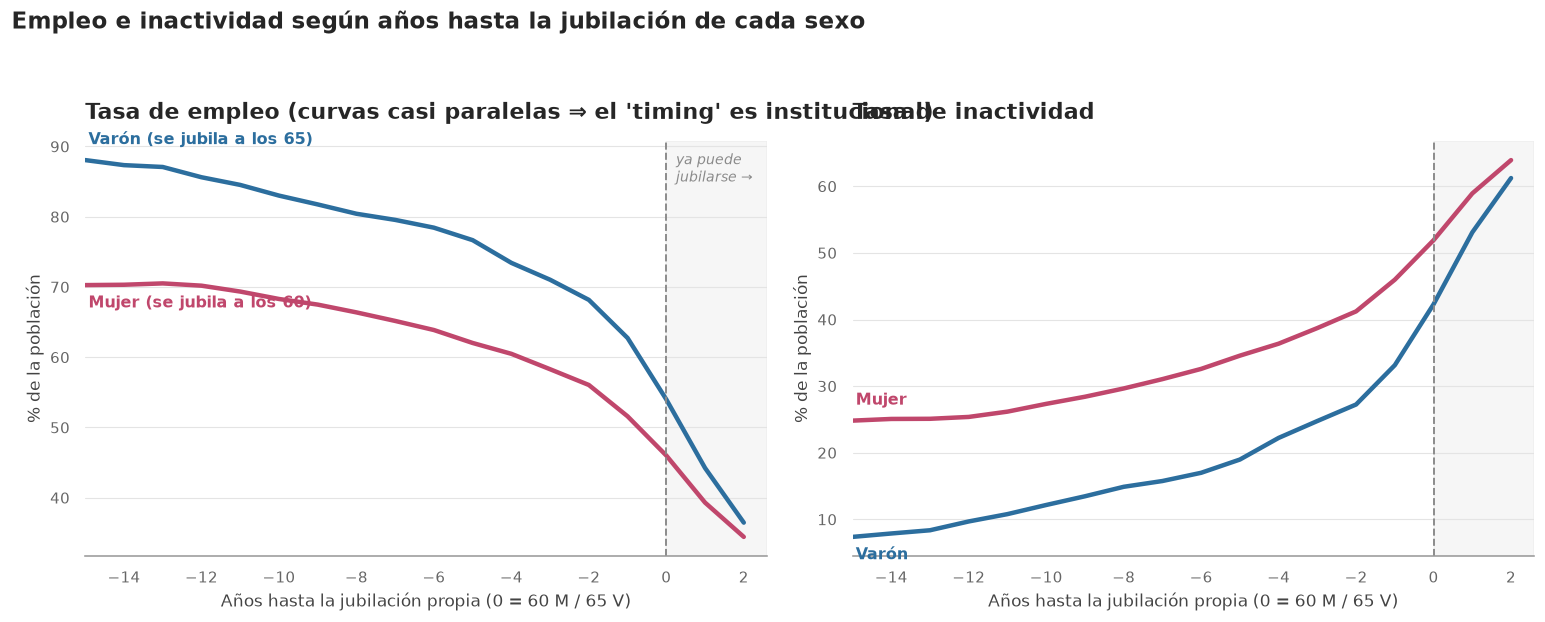

In [10]:
RET = {"Varón": 65, "Mujer": 60}                       # edad jubilatoria legal por sexo
emp = {sx: curva_empleo(sx) for sx in ["Varón", "Mujer"]}

# (a) Brecha de NIVEL de empleo en edades alejadas de la jubilación (no confundible)
print("Brecha de empleo lejos de la jubilación (no atribuible a la norma previsional):")
for lo, hi in [(35, 44), (45, 49)]:
    v, m = emp["Varón"].loc[lo:hi].mean(), emp["Mujer"].loc[lo:hi].mean()
    print(f"  {lo}-{hi}:  Varón {v:.0f}%   Mujer {m:.0f}%   brecha {v-m:.0f} pts")

# (b) Empleo alineado por AÑOS RESPECTO DE LA JUBILACIÓN PROPIA (t=0 = jubilación de cada sexo)
filas = [(t, emp["Varón"].get(RET["Varón"]+t, np.nan), emp["Mujer"].get(RET["Mujer"]+t, np.nan))
         for t in range(-12, 1, 2)]
align = pd.DataFrame(filas, columns=["t", "Varón", "Mujer"]).set_index("t")
print("\nEmpleo (%) ALINEADO por años a la jubilación propia (t=0 → 60 mujer / 65 varón):")
print(align.round(0).to_string())

# (c) Caída de empleo ANTES de poder jubilarse (penalización no institucional)
print("\nCaída de empleo desde el pico hasta la víspera de la jubilación propia:")
for sx in ["Varón", "Mujer"]:
    pico, visp = emp[sx].loc[35:50].max(), emp[sx].get(RET[sx]-1, np.nan)
    print(f"  {sx}: pico {pico:.0f}% → {RET[sx]-1} años {visp:.0f}%  "
          f"(−{pico-visp:.0f} pts ANTES de poder jubilarse)")

# Figura: empleo e inactividad ALINEADOS por años a la jubilación propia (superpuestos)
ina = {sx: (tasa_estado(df[df.sexo == sx], [3]).reindex(range(35, 71))
            .rolling(3, center=True, min_periods=1).mean()) for sx in RET}
fig, ax = plt.subplots(1, 2, figsize=(13.5, 5.2))
ts = list(range(-15, 3))
for sx, col in [("Varón", VAR), ("Mujer", MUJ)]:
    ye = [emp[sx].get(RET[sx] + t, np.nan) for t in ts]
    yi = [ina[sx].get(RET[sx] + t, np.nan) for t in ts]
    ax[0].plot(ts, ye, color=col, lw=2.8)
    ax[1].plot(ts, yi, color=col, lw=2.8)
    # etiqueta al INICIO de la línea (al final las curvas convergen y se pisarían)
    ax[0].annotate(f"{sx} (se jubila a los {RET[sx]})", (ts[0], ye[0]),
                   xytext=(2, 10 if sx == "Varón" else -14), textcoords="offset points",
                   color=col, fontweight="bold", fontsize=10)
    ax[1].annotate(sx, (ts[0], yi[0]),
                   xytext=(2, -14 if sx == "Varón" else 10), textcoords="offset points",
                   color=col, fontweight="bold", fontsize=10)
for a in ax:
    a.axvspan(0, 2.6, color=GRIS, alpha=.07, zorder=0)
    a.axvline(0, ls="--", c=GRIS, lw=1.2)
    a.set_xlim(-15, 2.6)
ax[0].text(0.25, ax[0].get_ylim()[1] - 1.5, "ya puede\njubilarse →", color=GRIS,
           fontsize=9, style="italic", va="top")
estilo_serie(ax[0], "Tasa de empleo (curvas casi paralelas ⇒ el 'timing' es institucional)",
             "Años hasta la jubilación propia (0 = 60 M / 65 V)", "% de la población")
estilo_serie(ax[1], "Tasa de inactividad",
             "Años hasta la jubilación propia (0 = 60 M / 65 V)", "% de la población")
fig.suptitle("Empleo e inactividad según años hasta la jubilación de cada sexo",
             x=0.005, ha="left", y=1.04, fontsize=14.5, fontweight="semibold")
plt.tight_layout(); plt.savefig(FIG / "empleo_alineado_jubilacion.png"); plt.show()

# Variables para las 'lecturas dinámicas' (celdas de texto generadas por código)
BRECHA_NIVEL = {f"{a}-{b}": emp["Varón"].loc[a:b].mean() - emp["Mujer"].loc[a:b].mean()
                for a, b in [(35, 44), (45, 49)]}
CAIDA_PRE = {sx: emp[sx].loc[35:50].max() - emp[sx].get(RET[sx] - 1, np.nan) for sx in RET}


In [11]:
# --- Lectura dinámica: las cifras se regeneran con los resultados de esta corrida ---
from IPython.display import Markdown
_b = (BRECHA_NIVEL['35-44'] + BRECHA_NIVEL['45-49']) / 2
_dk = BK['Varón']['aceleracion'] - BK['Mujer']['aceleracion']
Markdown(f"""**Lectura — controlando la edad jubilatoria.** Al separar lo **institucional** de lo
**discriminatorio** aparecen tres hechos:

1. **La brecha de nivel es enorme y no depende de la jubilación** — ya a los **35–49
   años** las mujeres tienen **~{_b:.0f} puntos menos** de empleo—, pero la sección 4.1
   mostró que es, ante todo, una brecha de **participación** (oferta y demanda
   mezcladas), no de desocupación: no debe leerse, por sí sola, como exclusión del
   mercado.
2. **El *timing* de la caída es, en gran medida, institucional.** Alineadas las curvas
   por *años a la jubilación propia*, los perfiles de descenso son prácticamente
   **paralelos**: que las mujeres se desplomen ~{_dk} años antes en edad absoluta refleja
   sobre todo que se jubilan cinco años antes, **no** una penalización temporal
   adicional. *(Esto corrige una lectura ingenua del gráfico anterior.)*
3. **Ambos sexos pierden mucho empleo ANTES de poder jubilarse — y, en puntos, MÁS los
   varones** (−{CAIDA_PRE['Varón']:.0f} pts vs. −{CAIDA_PRE['Mujer']:.0f} pts entre el pico y la víspera del retiro
   propio): hay una salida del mercado que la norma previsional no explica y que golpea
   **igual o más** a los varones (H1).

En síntesis: la dimensión **etaria** (caída prejubilatoria, común a ambos sexos y mayor
en varones) y la dimensión de **sexo** (participación, más el castigo de ingresos entre
ocupados de la sección 7) son fenómenos distintos. Atribuir la salida temprana femenina
a discriminación sería confundir la **ley** con el **mercado**.""")

**Lectura — controlando la edad jubilatoria.** Al separar lo **institucional** de lo
**discriminatorio** aparecen tres hechos:

1. **La brecha de nivel es enorme y no depende de la jubilación** — ya a los **35–49
   años** las mujeres tienen **~20 puntos menos** de empleo—, pero la sección 4.1
   mostró que es, ante todo, una brecha de **participación** (oferta y demanda
   mezcladas), no de desocupación: no debe leerse, por sí sola, como exclusión del
   mercado.
2. **El *timing* de la caída es, en gran medida, institucional.** Alineadas las curvas
   por *años a la jubilación propia*, los perfiles de descenso son prácticamente
   **paralelos**: que las mujeres se desplomen ~6 años antes en edad absoluta refleja
   sobre todo que se jubilan cinco años antes, **no** una penalización temporal
   adicional. *(Esto corrige una lectura ingenua del gráfico anterior.)*
3. **Ambos sexos pierden mucho empleo ANTES de poder jubilarse — y, en puntos, MÁS los
   varones** (−28 pts vs. −20 pts entre el pico y la víspera del retiro
   propio): hay una salida del mercado que la norma previsional no explica y que golpea
   **igual o más** a los varones (H1).

En síntesis: la dimensión **etaria** (caída prejubilatoria, común a ambos sexos y mayor
en varones) y la dimensión de **sexo** (participación, más el castigo de ingresos entre
ocupados de la sección 7) son fenómenos distintos. Atribuir la salida temprana femenina
a discriminación sería confundir la **ley** con el **mercado**.

In [12]:
# --- Lectura dinámica: umbrales tomados de BK (estimados en 4.2) ---
from IPython.display import Markdown
_ov, _om = BK['Varón']['inicio_descenso'], BK['Mujer']['inicio_descenso']
_kv, _km = BK['Varón']['aceleracion'], BK['Mujer']['aceleracion']
Markdown(f"""**Patrón de dos fases (descriptivo).** Más allá del control anterior, la curva de
empleo por edad muestra:

1. **Inicio temprano y gradual (~{(_ov + _om) // 2} años, en ambos sexos).** El empleo empieza a
   descender de forma sostenida desde alrededor de los **{min(_om, _ov)}–{max(_om, _ov)} años** (≈1 punto por
   año), bastante **antes** de cualquier edad jubilatoria. La penalización no arranca
   "cerca de la jubilación": arranca a mitad de la cincuentena.
2. **Aceleración tardía, a una distancia similar de la jubilación de cada sexo.** La
   caída se vuelve abrupta en un **quiebre que difiere en edad absoluta**: **mujeres
   ~{_km}**, **varones ~{_kv}**. Pero —como mostró el control anterior— esos ~{_kv - _km} años de
   diferencia **se corresponden con los 5 años de menor edad jubilatoria femenina**:
   relativo a la jubilación de cada uno, la aceleración ocurre a una distancia
   parecida. El *timing* es, por tanto, **mayormente institucional**.

La caída del empleo es, además, la contraparte de la "estabilidad" de la
desocupación: la salida se dirige hacia la **inactividad**, no hacia la búsqueda
activa. Estos umbrales (~{(_ov + _om) // 2}, ~{_km}, ~{_kv}) **no se fijaron de antemano**: se estimaron de
la curva. La señal de penalización **etaria**, recordemos, descansa en la caída previa
a la jubilación propia —común a ambos sexos y mayor en varones— y en el **castigo de
ingresos** (sección 7), no en este *timing*; la brecha de **nivel** entre sexos se lee
como participación (sección 4.1).""")


**Patrón de dos fases (descriptivo).** Más allá del control anterior, la curva de
empleo por edad muestra:

1. **Inicio temprano y gradual (~50 años, en ambos sexos).** El empleo empieza a
   descender de forma sostenida desde alrededor de los **49–51 años** (≈1 punto por
   año), bastante **antes** de cualquier edad jubilatoria. La penalización no arranca
   "cerca de la jubilación": arranca a mitad de la cincuentena.
2. **Aceleración tardía, a una distancia similar de la jubilación de cada sexo.** La
   caída se vuelve abrupta en un **quiebre que difiere en edad absoluta**: **mujeres
   ~56**, **varones ~62**. Pero —como mostró el control anterior— esos ~6 años de
   diferencia **se corresponden con los 5 años de menor edad jubilatoria femenina**:
   relativo a la jubilación de cada uno, la aceleración ocurre a una distancia
   parecida. El *timing* es, por tanto, **mayormente institucional**.

La caída del empleo es, además, la contraparte de la "estabilidad" de la
desocupación: la salida se dirige hacia la **inactividad**, no hacia la búsqueda
activa. Estos umbrales (~50, ~56, ~62) **no se fijaron de antemano**: se estimaron de
la curva. La señal de penalización **etaria**, recordemos, descansa en la caída previa
a la jubilación propia —común a ambos sexos y mayor en varones— y en el **castigo de
ingresos** (sección 7), no en este *timing*; la brecha de **nivel** entre sexos se lee
como participación (sección 4.1).

#### Robustez: ¿comparamos peras con peras? Lentes, normalización y cohortes

> 🧭 Someto la comparación entre sexos a tres controles. (1) **Lentes**: mido la caída de empleo del pico a la víspera de la jubilación propia en términos **absolutos por año** y **relativos al propio pico** (perder 20 pts sobre una base de 71 no es lo mismo que perder 28 sobre 90). (2) **Colinealidad**: dentro de cada sexo, la edad y los años hasta la jubilación difieren en una constante, así que ningún modelo puede separar el "reloj etario" del "reloj previsional" con un corte transversal — hay que decir explícitamente qué lente se usa. (3) **Cohortes**: aprovecho los 9 años de EPH para seguir a la **misma cohorte** (edad *a* en 2016 → *a+8* en 2024) y comparar contra el corte transversal; si la participación femenina creció generación a generación, la curva transversal de las mujeres exagera su "salida" del empleo.
>
> Sin estos controles, cualquier afirmación de "a quién le pega más" depende de una elección arbitraria de eje o de normalización — exactamente el tipo de conclusión frágil que un tribunal puede dar vuelta con una sola pregunta.

In [13]:
# --- Robustez: lentes de comparación (absoluta/relativa) y chequeo de cohortes ---
# (1) Lentes: caída pico → víspera de la jubilación propia
LENTES = {}
for sx in RET:
    s = emp[sx]
    pico_e = int(s.loc[35:50].idxmax()); pico = s.loc[35:50].max(); visp = s[RET[sx] - 1]
    n = RET[sx] - 1 - pico_e
    LENTES[sx] = {"anios": n, "abs_total": pico - visp, "abs_anual": (pico - visp) / n,
                  "rel_anual": 100 * (pico - visp) / pico / n}
print("Caída de empleo pico → víspera de la jubilación propia:")
for sx, L in LENTES.items():
    print(f"  {sx}: −{L['abs_total']:.1f} pts en {L['anios']} años "
          f"({L['abs_anual']:.2f} pts/año absoluto | {L['rel_anual']:.2f} %/año de su propio pico)")

# (2) Cohortes: la MISMA cohorte 2016→2024 vs. el corte transversal de 2016
def _curva_anio(sx, anio):
    d = df[(df.sexo == sx) & (df.anio == anio)].copy()
    d["w"] = d["PONDERA"].where(d["ESTADO"] == 1, 0)
    return (d.groupby("edad", observed=True)
             .apply(lambda x: 100 * x["w"].sum() / x["PONDERA"].sum(), include_groups=False)
             .reindex(range(35, 71)).rolling(3, center=True, min_periods=1).mean())
COHORTES = {}
print("\nCaída de empleo: cohorte REAL (2016→2024) vs. corte transversal (2016):")
for sx in RET:
    c16, c24 = _curva_anio(sx, 2016), _curva_anio(sx, 2024)
    COHORTES[sx] = {f"{a}→{a+8}": {"cohorte": c24[a + 8] - c16[a],
                                   "transversal": c16[a + 8] - c16[a]} for a in (48, 50, 52)}
    for k, v in COHORTES[sx].items():
        print(f"  {sx} {k}: cohorte {v['cohorte']:+.1f} pts | transversal {v['transversal']:+.1f} pts "
              f"| sesgo {v['cohorte'] - v['transversal']:+.1f}")

Caída de empleo pico → víspera de la jubilación propia:
  Varón: −27.7 pts en 24 años (1.16 pts/año absoluto | 1.28 %/año de su propio pico)
  Mujer: −19.9 pts en 17 años (1.17 pts/año absoluto | 1.64 %/año de su propio pico)

Caída de empleo: cohorte REAL (2016→2024) vs. corte transversal (2016):
  Varón 48→56: cohorte -8.2 pts | transversal -9.3 pts | sesgo +1.1
  Varón 50→58: cohorte -7.1 pts | transversal -9.2 pts | sesgo +2.2
  Varón 52→60: cohorte -10.0 pts | transversal -9.5 pts | sesgo -0.5
  Mujer 48→56: cohorte -4.2 pts | transversal -9.6 pts | sesgo +5.4
  Mujer 50→58: cohorte -3.3 pts | transversal -7.1 pts | sesgo +3.8
  Mujer 52→60: cohorte -11.6 pts | transversal -17.2 pts | sesgo +5.6


In [14]:
# --- Lectura dinámica: robustez, cifras de esta corrida ---
from IPython.display import Markdown
_LV, _LM = LENTES["Varón"], LENTES["Mujer"]
_cv48, _cm48 = COHORTES["Varón"]["48→56"], COHORTES["Mujer"]["48→56"]
Markdown(f"""**Lectura — ¿peras con peras?** Dentro de cada sexo, la edad y los años hasta la
jubilación propia son **perfectamente colineales** (t = edad − 60/65): ningún corte
transversal puede separar el "reloj etario" del "reloj previsional". Lo que sí puede
hacerse es mirar con varios lentes y quedarse con lo que resiste a todos:

1. **Intensidad anual absoluta: empate.** Del pico a la víspera del retiro propio, el
   empleo cae **{_LV['abs_anual']:.2f} pts/año en varones y {_LM['abs_anual']:.2f} pts/año en mujeres**. Los varones
   acumulan más caída total (−{_LV['abs_total']:.0f} vs. −{_LM['abs_total']:.0f} pts) porque su rampa dura **{_LV['anios']} años
   contra {_LM['anios']}**: no los penalizan más por año — están **expuestos cinco años más**.
2. **Normalización relativa: parecería desfavorecer a las mujeres…** Relativa al propio
   pico, la caída femenina luce más veloz ({_LM['rel_anual']:.1f} vs. {_LV['rel_anual']:.1f} %/año), porque su base
   de partida es menor (71% vs. 90%).
3. **…hasta que se controla el efecto cohorte.** Siguiendo a la **misma cohorte**
   (2016→2024), a los 48→56 los varones pierden {_cv48['cohorte']:+.1f} pts (el corte transversal
   decía {_cv48['transversal']:+.1f}: coinciden), pero las mujeres pierden {_cm48['cohorte']:+.1f} pts contra
   {_cm48['transversal']:+.1f} del corte: **cerca de la mitad de la "caída" femenina por edad es
   composición de cohortes** — generaciones mayores que participaron menos toda su vida,
   no mujeres que "salieron" del empleo. El perfil masculino, con participación
   históricamente estable, no arrastra ese sesgo; la lente relativa, al dividir por una
   base menor, **amplifica justamente la parte espuria**. *Caveat:* el seguimiento de
   cohortes mezcla envejecimiento con efecto período (2016–2024); cohorte y transversal
   se leen como **cotas** de la caída real.

**Síntesis de robustez.** Ninguna lente muestra a los varones sufriendo *menos*
penalización etaria: empate en intensidad anual, **mayor exposición acumulada** (cinco
años más de rampa hasta los 65) y, siguiendo cohortes a igual edad, caída masculina
**igual o mayor**. La única lente que sugería lo contrario —la relativa transversal— es
la que el sesgo de cohortes infla. H1 queda sostenida en su forma fuerte.""")

**Lectura — ¿peras con peras?** Dentro de cada sexo, la edad y los años hasta la
jubilación propia son **perfectamente colineales** (t = edad − 60/65): ningún corte
transversal puede separar el "reloj etario" del "reloj previsional". Lo que sí puede
hacerse es mirar con varios lentes y quedarse con lo que resiste a todos:

1. **Intensidad anual absoluta: empate.** Del pico a la víspera del retiro propio, el
   empleo cae **1.16 pts/año en varones y 1.17 pts/año en mujeres**. Los varones
   acumulan más caída total (−28 vs. −20 pts) porque su rampa dura **24 años
   contra 17**: no los penalizan más por año — están **expuestos cinco años más**.
2. **Normalización relativa: parecería desfavorecer a las mujeres…** Relativa al propio
   pico, la caída femenina luce más veloz (1.6 vs. 1.3 %/año), porque su base
   de partida es menor (71% vs. 90%).
3. **…hasta que se controla el efecto cohorte.** Siguiendo a la **misma cohorte**
   (2016→2024), a los 48→56 los varones pierden -8.2 pts (el corte transversal
   decía -9.3: coinciden), pero las mujeres pierden -4.2 pts contra
   -9.6 del corte: **cerca de la mitad de la "caída" femenina por edad es
   composición de cohortes** — generaciones mayores que participaron menos toda su vida,
   no mujeres que "salieron" del empleo. El perfil masculino, con participación
   históricamente estable, no arrastra ese sesgo; la lente relativa, al dividir por una
   base menor, **amplifica justamente la parte espuria**. *Caveat:* el seguimiento de
   cohortes mezcla envejecimiento con efecto período (2016–2024); cohorte y transversal
   se leen como **cotas** de la caída real.

**Síntesis de robustez.** Ninguna lente muestra a los varones sufriendo *menos*
penalización etaria: empate en intensidad anual, **mayor exposición acumulada** (cinco
años más de rampa hasta los 65) y, siguiendo cohortes a igual edad, caída masculina
**igual o mayor**. La única lente que sugería lo contrario —la relativa transversal— es
la que el sesgo de cohortes infla. H1 queda sostenida en su forma fuerte.

### 4.3 Ingreso relativo por edad y sexo — *descenso en torno a la edad jubilatoria*

> 🧭 Construyo el **ingreso relativo**: divido el ingreso de cada ocupado (`P21`) por la **mediana de los ocupados de su mismo trimestre**. Así, un valor de 1,0 significa 'gana como la mediana de ese trimestre'. Luego lo promedio por edad y sexo, ponderado por el factor de ingresos `PONDIIO`. Entre 2016 y 2024 la inflación fue altísima, por lo que **no puedo comparar pesos nominales** de distintos trimestres. Normalizar contra la mediana de cada trimestre elimina la inflación y deja una escala comparable a lo largo de los nueve años. Uso `PONDIIO` porque es el ponderador específico para variables de ingreso.
>
> Si comparara montos nominales, la inflación dominaría todo y confundiría 'subió el ingreso' con 'subieron los precios', invalidando cualquier conclusión sobre la brecha por edad o sexo.

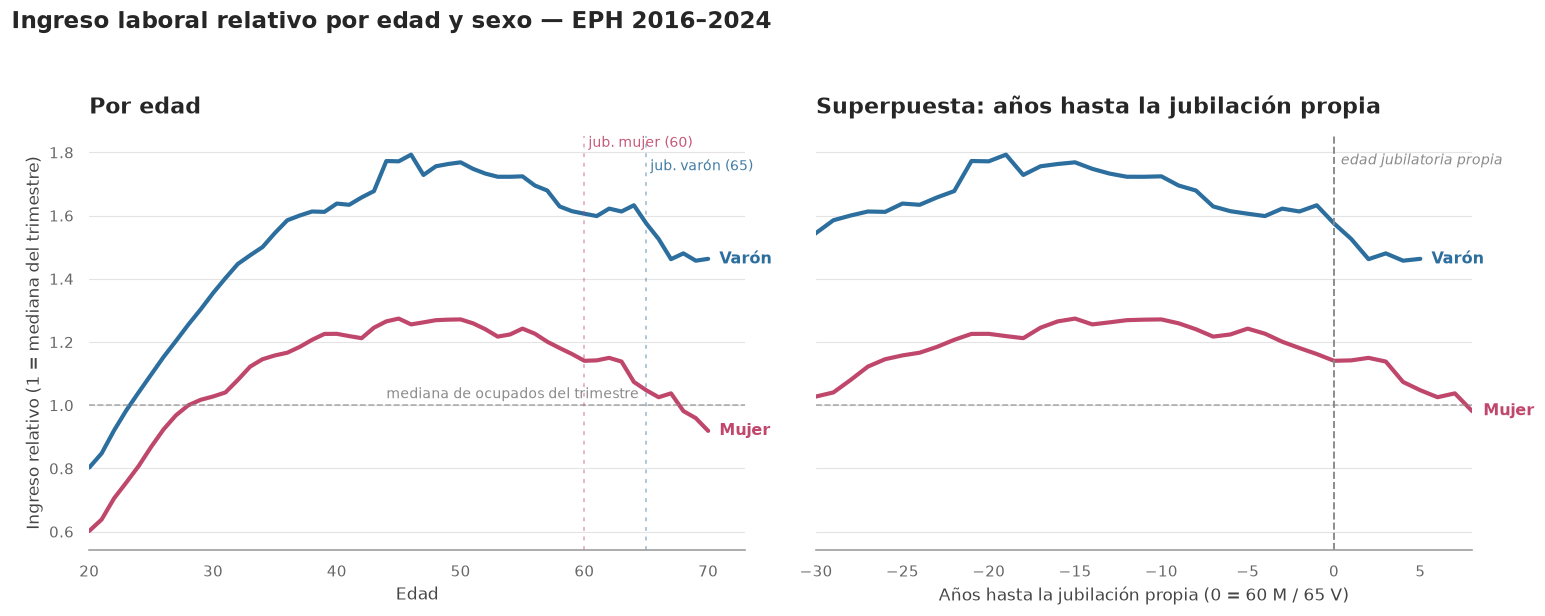

Ingreso relativo mediano por franja y sexo
sexo    Mujer  Varón
franja              
25-49   0.890  1.200
50-59   1.000  1.270
60-64   0.820  1.200
65-70   0.620  1.000


In [15]:
# Ingreso relativo a la mediana de ocupados de CADA trimestre (elimina inflación)
ocup = df[(df.ESTADO == 1) & (df.P21 > 0)].copy()
med = ocup.groupby(["anio", "trimestre"])["P21"].transform("median")
ocup["ingreso_rel"] = ocup["P21"] / med

edades = range(20, 71)
fig, ax = plt.subplots(1, 2, figsize=(13.5, 5.2), sharey=True)
for sx, col in [("Varón", VAR), ("Mujer", MUJ)]:
    serie = (ocup[ocup.sexo == sx].groupby("edad").apply(
        lambda x: np.average(x["ingreso_rel"], weights=x["PONDIIO"]), include_groups=False)
        .reindex(edades).rolling(3, center=True, min_periods=1).mean())
    ax[0].plot(list(edades), serie.values, color=col, lw=2.6)
    fin_de_linea(ax[0], 70, serie.iloc[-1], sx, col)
    # panel derecho: la MISMA curva con el eje corrido a años hasta la jubilación propia
    ts = [e - RET[sx] for e in edades]
    ax[1].plot(ts, serie.values, color=col, lw=2.6)
    t_lab = 5 if sx == "Varón" else 8
    fin_de_linea(ax[1], t_lab, serie.values[list(edades).index(RET[sx] + t_lab)], sx, col)
for a in ax:
    a.axhline(1.0, c=GRIS, lw=1, ls="--", alpha=.7)
ax[0].text(44, 1.012, "mediana de ocupados del trimestre", color=GRIS, fontsize=8.5, va="bottom")
for x, col in [(60, MUJ), (65, VAR)]:
    ax[0].axvline(x, ls=(0, (2, 3)), c=col, alpha=.4, lw=1.2)
ax[0].text(60, ax[0].get_ylim()[1], " jub. mujer (60)", color=MUJ, fontsize=8.5, va="top", alpha=.9)
ax[0].text(65, ax[0].get_ylim()[1] * .96, " jub. varón (65)", color=VAR, fontsize=8.5, va="top", alpha=.9)
ax[1].axvline(0, ls="--", c=GRIS, lw=1.2)
ax[1].text(0.4, ax[1].get_ylim()[1] * .97, "edad jubilatoria propia", color=GRIS,
           fontsize=8.5, va="top", style="italic")
estilo_serie(ax[0], "Por edad", "Edad", "Ingreso relativo (1 = mediana del trimestre)")
estilo_serie(ax[1], "Superpuesta: años hasta la jubilación propia",
             "Años hasta la jubilación propia (0 = 60 M / 65 V)", "")
ax[0].set_xlim(20, 73); ax[1].set_xlim(-30, 8)
fig.suptitle("Ingreso laboral relativo por edad y sexo — EPH 2016–2024",
             x=0.005, ha="left", y=1.03, fontsize=14.5, fontweight="semibold")
plt.tight_layout(); plt.savefig(FIG / "ingreso_edad_sexo.png"); plt.show()

# Franjas alineadas con los quiebres estimados (sin el "58" a priori)
ocup["franja"] = pd.cut(ocup.edad, bins=[25, 50, 60, 65, 71],
                        labels=["25-49", "50-59", "60-64", "65-70"], right=False)
piv = ocup.groupby(["franja", "sexo"], observed=True)["ingreso_rel"].median().unstack()
print("Ingreso relativo mediano por franja y sexo"); print(piv.round(2).to_string())

El ingreso relativo aumenta con la experiencia, alcanza su máximo en la madurez y
**desciende en torno a la edad jubilatoria**. La curva correspondiente a las
mujeres se ubica **por debajo** de la de los varones en casi todo el recorrido: la
brecha de sexo ya se observa en el análisis descriptivo, junto con la de edad. El
paso siguiente consiste en separar qué proporción obedece a la composición
(educación, región) y qué proporción constituye un efecto **neto**.

## 5. Modelo A — Ingreso (regresión)

**Tarea.** Predecir el **ingreso laboral relativo** de las personas ocupadas de
**25 a 70 años** a partir de edad, sexo, nivel educativo, región y año.
**Métrica:** R². El objetivo no es sólo predecir bien, sino medir el **efecto
neto** de sexo y edad una vez controlada la calificación (vía importancia de
variables). El target se **winsoriza a [p1, p99]**: el ingreso relativo tiene colas
muy largas (hasta ~131× la mediana) que, sin recortar, dominan el error cuadrático
y hunden el R² de los modelos basados en árboles.

> 🧭 Armo el conjunto de entrenamiento del Modelo A: me quedo con los **ocupados de 25 a 70 años**, defino como variable a predecir (`target`) el ingreso relativo y como predictores edad, sexo, nivel educativo, región y año. Antes de entrenar **winsorizo** el target, es decir, recorto los valores por debajo del percentil 1 y por encima del 99 a esos límites; los límites se calculan **sólo con el conjunto de entrenamiento** (después de separar el test) y se aplican a ambos, para no filtrar información del test hacia el entrenamiento. Acoto la edad a 25–70 para concentrarme en la vida laboral plena. Winsorizo porque el ingreso relativo tiene colas larguísimas (hay casos de hasta ~131× la mediana); como la métrica R² penaliza el **error al cuadrado**, esos pocos extremos dominan el ajuste. Recortar las colas es una técnica estándar para que el modelo capture el patrón central en vez de perseguir outliers.
>
> Sin winsorizar, los modelos basados en árboles daban incluso **R² negativo** (peores que predecir la media): los outliers inflaban el error y ocultaban la señal real de edad y sexo.

In [16]:
REGION = {1:"GBA", 40:"Noroeste", 41:"Nordeste", 42:"Cuyo", 43:"Pampeana", 44:"Patagonia"}

reg = ocup[ocup.edad.between(25, 70)].copy()
reg["region"] = reg["REGION"].map(REGION)
reg = reg.rename(columns={"ingreso_rel": "target"})
Xr = reg[["edad", "sexo", "nivel_ed", "region", "anio"]].copy()
yr = reg["target"]
mask = Xr.notna().all(axis=1) & yr.notna()
Xr, yr = Xr[mask], yr[mask]

n_full_r = len(Xr)
if P["n_modelo"] and n_full_r > P["n_modelo"]:           # submuestreo según el modo
    Xr = Xr.sample(P["n_modelo"], random_state=SEED); yr = yr.loc[Xr.index]
det = "dataset completo" if len(Xr) == n_full_r else f"submuestra {len(Xr):,} (modo {MODO})"
print(f"Cohorte de ingreso (ocupados 25–70): {n_full_r:,} disponibles → {det}")
print(yr.describe()[["mean","std","min","50%","max"]].round(2).to_string())

Cohorte de ingreso (ocupados 25–70): 555,029 disponibles → dataset completo
mean     1.270
std      1.120
min      0.000
50%      1.060
max    131.150


> 🧭 Defino dos herramientas reutilizables. (1) Un **preprocesador**: a las variables numéricas les imputo faltantes con la mediana y las **estandarizo** (resto la media y divido por el desvío, para que todas estén en la misma escala); a las categóricas (sexo, nivel educativo, región) les aplico **one-hot encoding** (las convierto en columnas 0/1). (2) Una función `comparar()` que evalúa cada modelo por **validación cruzada** (cv=5): parte los datos en 5 bloques y entrena/evalúa 5 veces, rotando el bloque de prueba. Empaqueto el preprocesamiento en un `Pipeline` para que se ajuste **sólo con los datos de entrenamiento** dentro de cada partición, evitando fuga de información. Estandarizo porque modelos como KNN o SVM dependen de distancias y se rompen si una variable tiene una escala mucho mayor. Uso validación cruzada porque una única partición train/test daría una estimación ruidosa, dependiente del azar del corte.
>
> Sin pipeline, escalar o imputar con el dataset completo filtraría información del test al entrenamiento y **inflaría artificialmente** las métricas. Sin validación cruzada, podría elegir un modelo que sólo tuvo suerte con una partición concreta.

In [17]:
# --- Preprocesador: imputación + estandarización (numéricas) y one-hot denso
#     (categóricas; denso para que HistGradientBoosting acepte la matriz) ---
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split

def build_prep(X):
    num = X.select_dtypes("number").columns.tolist()
    cat = X.select_dtypes(exclude="number").columns.tolist()
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler())]), num),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat),
    ])

def comparar(X, y, modelos, scoring, cv=5, sub_sizes=None):
    # CV para cada modelo. KNN (costo en predicción) y SVM-RBF (kernel O(n^2-n^3))
    # se evalúan sobre un subconjunto, documentado en la columna 'nota'.
    sub_sizes = sub_sizes or {"knn": 80_000, "svm_rbf": 12_000}
    filas = []
    for nombre, est in modelos.items():
        Xi, yi, nota = X, y, ""
        n = sub_sizes.get(nombre)
        if n and len(X) > n:
            idx = X.sample(n, random_state=SEED).index
            Xi, yi, nota = X.loc[idx], y.loc[idx], f"(subconj. {n:,})"
        pipe = Pipeline([("prep", build_prep(Xi)), ("model", est)])
        sc = cross_val_score(pipe, Xi, yi, cv=cv, scoring=scoring, n_jobs=-1)
        filas.append((nombre, sc.mean(), sc.std(), nota))
        print(f"  {nombre:20} {scoring}={sc.mean():.3f} ± {sc.std():.3f} {nota}")
    return pd.DataFrame(filas, columns=["modelo", scoring, "std", "nota"])

**Familia de modelos comparados** (todos clásicos, *sin redes neuronales*). Para
cubrir el programa de la cátedra incluimos un **árbol de decisión único** (Clase 4)
y dos variantes de **SVM** (Clase 3): la **lineal** (`SGDRegressor` con pérdida *ε-insensible*, es decir una SVR lineal
entrenada por gradiente estocástico, escalable a millones de filas) y la de **kernel RBF** (`SVR`). El SVM de kernel tiene costo
de entrenamiento ~O(n²–n³), inviable sobre 555k filas, así que se evalúa sobre un
**subconjunto de 12 000** (criterio documentado); esto justamente motiva usar la
SVM lineal en el dataset completo. KNN también se acota por su costo en predicción.

> 🧭 Separo un 20% de los datos como **test reservado** (que no toco hasta el final) y, sobre el 80% restante, comparo por validación cruzada un **baseline** (predecir siempre la media) contra varios modelos: regresión lineal, KNN, dos SVM (lineal y kernel RBF), un árbol de decisión y dos *ensambles* (Random Forest y Gradient Boosting). La métrica es **R²**: la proporción de varianza del ingreso que el modelo explica (0 = no mejor que la media; 1 = perfecto). Incluyo el baseline porque un modelo sólo 'sirve' si le gana a una regla trivial; es mi vara de comparación. Pruebo familias de modelos distintas (lineales, basados en distancias, en árboles) porque a priori no sé cuál capta mejor la estructura de los datos, y la consigna pide comparar al menos tres. Reservo el test desde el inicio para tener una estimación honesta de generalización.
>
> Sin baseline, un R² 'que parece bueno' podría no superar a predecir la media. Sin test reservado, ajustaría y elegiría modelos mirando los mismos datos con que los evalúo, sobrestimando su desempeño (sobreajuste).

In [18]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

# 20% reservado como test (no se toca hasta la evaluación final); 80% para CV/tuning
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.2, random_state=SEED)

# (corrección v2.2) Winsorización del target a [p1, p99] calculados SÓLO sobre el
# train y aplicados a train y test: evita la (leve) fuga de calcular los límites
# con el test incluido. Sin winsorizar, las colas extremas del ingreso relativo
# (hasta ~131× la mediana) dominan el error cuadrático y hacían NEGATIVO el R²
# del árbol y del Random Forest.
lo, hi = yr_tr.quantile([0.01, 0.99])
n_clip = int((yr_tr < lo).sum() + (yr_tr > hi).sum() + (yr_te < lo).sum() + (yr_te > hi).sum())
yr_tr, yr_te = yr_tr.clip(lo, hi), yr_te.clip(lo, hi)
print(f"Target winsorizado a [p1, p99] = [{lo:.2f}, {hi:.2f}] del TRAIN ({n_clip:,} valores recortados)")

modelos_reg = {
    "baseline (media)":   DummyRegressor(strategy="mean"),
    "linear_regression":  LinearRegression(),
    "svm_lineal (SGD)":   SGDRegressor(loss="epsilon_insensitive",   # pérdida ε-insensible = SVR lineal
                                   random_state=SEED, max_iter=2000),
    "svm_rbf":            SVR(kernel="rbf", C=5),
    "arbol_decision":     DecisionTreeRegressor(max_depth=5, min_samples_leaf=50, random_state=SEED),
    "knn":                KNeighborsRegressor(n_neighbors=25),
    "random_forest":      RandomForestRegressor(n_estimators=200, min_samples_leaf=50, n_jobs=-1, random_state=SEED),
    "hist_grad_boosting": HistGradientBoostingRegressor(random_state=SEED),
}
print("Validación cruzada (R², cv=5) — cohorte de ocupados 25–70:")
res_reg = comparar(Xr_tr, yr_tr, modelos_reg, scoring="r2",
                   sub_sizes={"knn": 80_000, "svm_rbf": P["sub_svm_rbf"]})

Target winsorizado a [p1, p99] = [0.08, 5.00] del TRAIN (9,866 valores recortados)
Validación cruzada (R², cv=5) — cohorte de ocupados 25–70:


  baseline (media)     r2=-0.000 ± 0.000 


  linear_regression    r2=0.271 ± 0.003 


  svm_lineal (SGD)     r2=0.249 ± 0.003 


  svm_rbf              r2=0.245 ± 0.015 (subconj. 12,000)


  arbol_decision       r2=0.247 ± 0.002 


  knn                  r2=0.272 ± 0.003 (subconj. 80,000)


  random_forest        r2=0.291 ± 0.003 


  hist_grad_boosting   r2=0.294 ± 0.003 


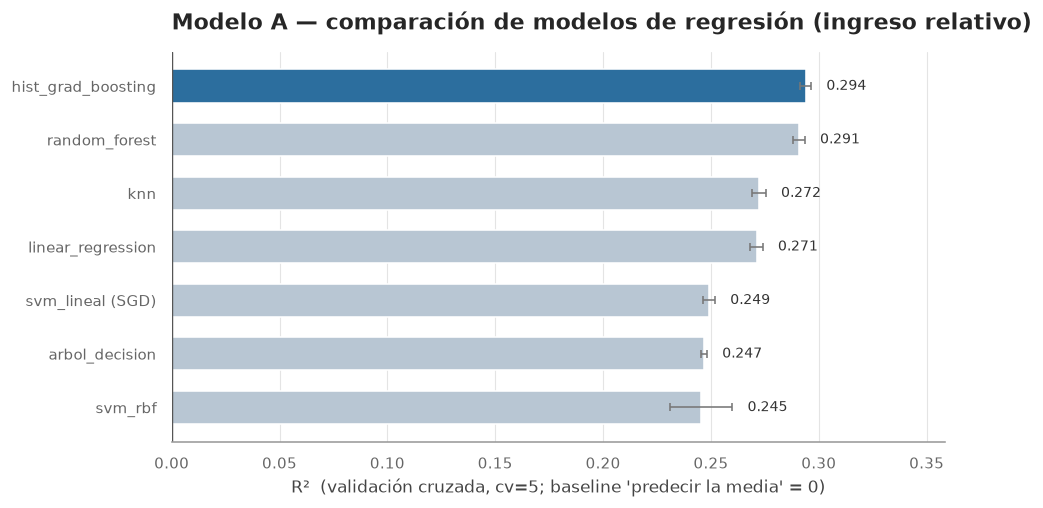

Baseline (predecir la media): R² = -0.000 (≈0 por construcción)


In [19]:
# --- Comparación visual de R² (CV): el mejor modelo resaltado, valores al final ---
r = res_reg[res_reg.modelo != "baseline (media)"].sort_values("r2").reset_index(drop=True)
fig, ax = plt.subplots(figsize=(8.5, 4.6))
colores = [VAR if i == r["r2"].idxmax() else "#B8C6D3" for i in r.index]
ax.barh(r.modelo, r.r2, xerr=r["std"], color=colores, height=0.62,
        error_kw=dict(ecolor="#777", lw=1, capsize=2.5))
for i, (v, e) in enumerate(zip(r.r2, r["std"])):
    ax.text(v + e + 0.007, i, f"{v:.3f}", va="center", fontsize=9, color="#333")
ax.grid(False, axis="y"); ax.grid(True, axis="x")
ax.axvline(0, c="#555", lw=.9)
ax.set_xlim(0, r.r2.max() * 1.22)
ax.set_xlabel("R²  (validación cruzada, cv=5; baseline 'predecir la media' = 0)")
ax.set_title("Modelo A — comparación de modelos de regresión (ingreso relativo)")
plt.tight_layout(); plt.savefig(FIG / "modeloA_comparacion_r2.png", dpi=150); plt.show()
base = res_reg.loc[res_reg.modelo == "baseline (media)", "r2"].iloc[0]
print(f"Baseline (predecir la media): R² = {base:.3f} (≈0 por construcción)")


> 🧭 **Tuneo** (ajusto los hiperparámetros) del mejor modelo —Gradient Boosting— con `GridSearchCV`: pruebo, por validación cruzada, varias combinaciones de tasa de aprendizaje, número de iteraciones y complejidad de los árboles, y me quedo con la mejor. Recién entonces evalúo ese modelo en el **test reservado**. Los hiperparámetros por defecto rara vez son los óptimos para un problema concreto; buscarlos sistemáticamente suele mejorar el desempeño. Hago la búsqueda con validación cruzada **dentro del entrenamiento** y mido una sola vez en el test, que permaneció intacto, para reportar una estimación insesgada de cómo generalizaría a datos nuevos.
>
> Si eligiera los hiperparámetros mirando el test, ese conjunto dejaría de ser independiente y el R² reportado sería optimista (sobreajuste a la evaluación).

In [20]:
# --- Tuning del mejor modelo (HistGradientBoosting) con GridSearchCV ---
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error

grid = ({                                  # grilla completa (modo completo)
    "model__learning_rate": [0.02, 0.05, 0.1],   # ampliada: el óptimo caía en el borde
    "model__max_iter": [200, 400],
    "model__max_leaf_nodes": [31, 63, 127],
} if P["grid_full"] else {                  # grilla mínima (modo rápido): 2 combos
    "model__learning_rate": [0.1],
    "model__max_iter": [200],
    "model__max_leaf_nodes": [31, 63],
})
gs_reg = GridSearchCV(
    Pipeline([("prep", build_prep(Xr_tr)), ("model", HistGradientBoostingRegressor(random_state=SEED))]),
    grid, cv=3, scoring="r2", n_jobs=-1)
gs_reg.fit(Xr_tr, yr_tr)
print("Mejores hiperparámetros:", gs_reg.best_params_)
print(f"R² (CV)   : {gs_reg.best_score_:.3f}")
pred_te = gs_reg.predict(Xr_te)
r2_test, mae_test = r2_score(yr_te, pred_te), mean_absolute_error(yr_te, pred_te)
print(f"R² (TEST) : {r2_test:.3f}")
print(f"MAE (TEST): {mae_test:.3f} (en unidades de mediana del trimestre)")

/Users/gv/projects/ceia_add/ML FIUBA/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Mejores hiperparámetros: {'model__learning_rate': 0.02, 'model__max_iter': 400, 'model__max_leaf_nodes': 63}
R² (CV)   : 0.294
R² (TEST) : 0.293
MAE (TEST): 0.551 (en unidades de mediana del trimestre)


> 🧭 Mido la **importancia de cada variable por permutación**: barajo al azar los valores de una columna (rompiendo su relación con el target) y observo cuánto cae el R². Cuanto más cae, más importante era esa variable. Es la pregunta clave del trabajo: ¿cuánto pesa el **sexo** una vez controlados educación, región y año? Uso permutación porque es **agnóstica al modelo** (vale para cualquiera) y mide la contribución real a la predicción, no un número interno del algoritmo. Que el sexo conserve importancia tras controlar por calificación es, justamente, la huella del **efecto neto** que busco medir.
>
> Las importancias internas de algunos modelos (p. ej. las de árboles por número de cortes) están sesgadas hacia variables con muchas categorías o escala continua; fiarme de ellas podría exagerar o esconder el verdadero peso del sexo.

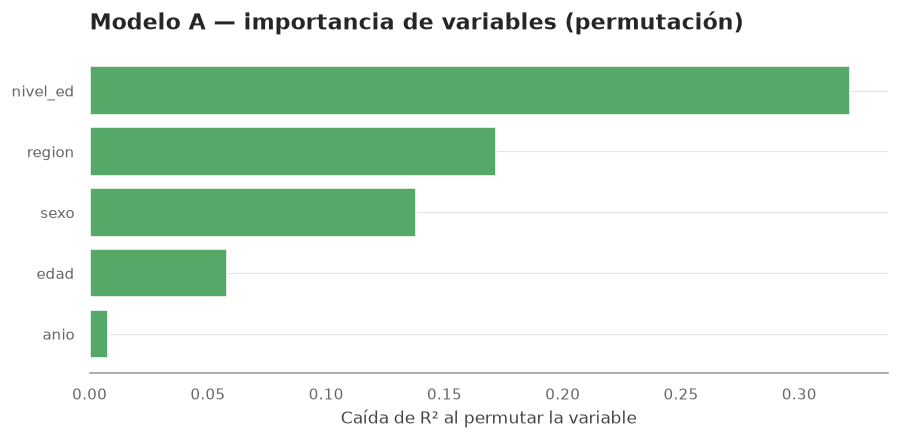

nivel_ed   0.321
region     0.172
sexo       0.138
edad       0.058
anio       0.008


In [21]:
# --- Importancia por permutación: ¿pesa el sexo tras controlar calificación? ---
from sklearn.inspection import permutation_importance

# subconjunto del test para acotar el costo de la permutación
n_perm = min(40_000, len(Xr_te))
Xp = Xr_te.sample(n_perm, random_state=SEED); yp = yr_te.loc[Xp.index]
imp = permutation_importance(gs_reg.best_estimator_, Xp, yp, n_repeats=P["perm_repeats"],
                             random_state=SEED, scoring="r2", n_jobs=-1)
imp_s = pd.Series(imp.importances_mean, index=Xr.columns).sort_values()
plt.figure(figsize=(8, 4))
plt.barh(imp_s.index, imp_s.values, color="#55A868")
plt.xlabel("Caída de R² al permutar la variable")
plt.title("Modelo A — importancia de variables (permutación)")
plt.tight_layout(); plt.savefig(FIG / "modeloA_importancia.png", dpi=120); plt.show()
print(imp_s.sort_values(ascending=False).round(4).to_string())

In [22]:
# --- Lectura dinámica: R², MAE e importancias tomados de esta corrida ---
from IPython.display import Markdown
_top = imp_s.sort_values(ascending=False)
Markdown(f"""**Lectura.** El baseline (predecir la media) da R² ≈ 0; el mejor modelo
(HistGradientBoosting tuneado) alcanza **R² = {r2_test:.2f} en test** (MAE = {mae_test:.2f} medianas),
explicando una parte sustantiva de la varianza del ingreso relativo con sólo cinco
variables. En la importancia por permutación dominan **{_top.index[0]}** ({_top.iloc[0]:.2f}) y
**{_top.index[1]}** ({_top.iloc[1]:.2f}), pero —y esto es lo central para la hipótesis— el **sexo**
({imp_s['sexo']:.2f}) pesa *más que la edad* ({imp_s['edad']:.2f}) y mantiene un peso claramente no
nulo *después* de controlar por educación, región y año: es la huella de una brecha de
ingreso que **no se explica sólo por diferencias de calificación**. Lo cuantificamos
formalmente con Oaxaca–Blinder (sección 7).

*Nota técnica:* la caída de R² al permutar una variable puede superar el R² total del
modelo (las predicciones degradadas pueden ser peores que predecir la media); no es
una inconsistencia.""")


**Lectura.** El baseline (predecir la media) da R² ≈ 0; el mejor modelo
(HistGradientBoosting tuneado) alcanza **R² = 0.29 en test** (MAE = 0.55 medianas),
explicando una parte sustantiva de la varianza del ingreso relativo con sólo cinco
variables. En la importancia por permutación dominan **nivel_ed** (0.32) y
**region** (0.17), pero —y esto es lo central para la hipótesis— el **sexo**
(0.14) pesa *más que la edad* (0.06) y mantiene un peso claramente no
nulo *después* de controlar por educación, región y año: es la huella de una brecha de
ingreso que **no se explica sólo por diferencias de calificación**. Lo cuantificamos
formalmente con Oaxaca–Blinder (sección 7).

*Nota técnica:* la caída de R² al permutar una variable puede superar el R² total del
modelo (las predicciones degradadas pueden ser peores que predecir la media); no es
una inconsistencia.

## 6. Modelo B — Exclusión del empleo (clasificación 35–64)

**Tarea.** Clasificar **ocupado (1) vs. no-ocupado (0)** en la franja **35–64**
(se excluye 65+ para no confundir la salida del mercado con la jubilación),
utilizando únicamente variables sin fuga de información: edad, sexo, nivel
educativo, región y año. **Métrica: ROC-AUC** (las clases están desbalanceadas; a
continuación se explica por qué la exactitud resulta engañosa).

*Nota (Clase 2):* en su formulación básica KNN no produce probabilidades y, en ese
sentido, "no tiene curva ROC". Aquí su ROC-AUC se calcula con la salida de
`predict_proba` de scikit-learn —la **fracción de los k=25 vecinos** que vota cada
clase—, medida sobre variables previamente estandarizadas por el pipeline (es
decir, distancia euclidiana entre features comparables).

> 🧭 Construyo el problema de clasificación: en la franja **35–64**, etiqueto a cada persona como ocupada (1) o no-ocupada (0) y predigo esa etiqueta a partir de edad, sexo, nivel educativo, región y año. Reviso además qué proporción de cada clase hay. La métrica será **ROC-AUC** (probabilidad de que el modelo le asigne más chance de empleo a un ocupado al azar que a un no-ocupado al azar; 0,5 = azar, 1 = perfecto). Acoto a 35–64 para **no confundir la salida del mercado con la jubilación** (65+). Excluyo a propósito variables como categoría ocupacional o descuento jubilatorio porque sólo existen si la persona ya trabaja: usarlas sería *data leakage* (predecir el empleo con información que presupone empleo). Elijo ROC-AUC porque, con clases desbalanceadas, la exactitud premia al modelo trivial que dice 'todos ocupados'.
>
> Con fuga de información tendría un modelo de métricas brillantes pero inútil y tramposo. Y si me guiara por la exactitud, podría 'ganar' simplemente prediciendo la clase mayoritaria, sin aprender nada sobre la exclusión por edad o sexo.

In [23]:
emp = df[df.ESTADO.isin([1, 2, 3]) & df.edad.between(35, 64)].copy()
emp["target"] = (emp.ESTADO == 1).astype(int)      # 1 = ocupado, 0 = no ocupado
emp["region"] = emp["REGION"].map(REGION)
Xc = emp[["edad", "sexo", "nivel_ed", "region", "anio"]].copy()
yc = emp["target"]
mask = Xc.notna().all(axis=1) & yc.notna()
Xc, yc = Xc[mask], yc[mask]
n_full_c = len(Xc)
if P["n_modelo"] and n_full_c > P["n_modelo"]:           # submuestreo según el modo
    Xc = Xc.sample(P["n_modelo"], random_state=SEED); yc = yc.loc[Xc.index]
det = "dataset completo" if len(Xc) == n_full_c else f"submuestra {len(Xc):,} (modo {MODO})"
print(f"Cohorte de empleo (35–64): {n_full_c:,} disponibles → {det}")
print("\nDistribución del target:")
print(yc.value_counts(normalize=True).rename({1:"ocupado", 0:"no ocupado"}).round(3).to_string())
print(f"\n→ Una regla trivial 'todos ocupados' alcanzaría {100*yc.mean():.0f}% de exactitud:")
print("  por ello la exactitud resulta engañosa y se adopta ROC-AUC, que mide la")
print("  separación de clases con independencia del umbral y del desbalance.")

Cohorte de empleo (35–64): 634,593 disponibles → dataset completo

Distribución del target:
target
ocupado      0.730
no ocupado   0.270

→ Una regla trivial 'todos ocupados' alcanzaría 73% de exactitud:
  por ello la exactitud resulta engañosa y se adopta ROC-AUC, que mide la
  separación de clases con independencia del umbral y del desbalance.


In [24]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (RandomForestClassifier, HistGradientBoostingClassifier,
                              VotingClassifier)

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.2, random_state=SEED, stratify=yc)

# Mismo set ampliado que en el Modelo A: árbol de decisión único (Clase 4),
# SVM lineal + SVM-RBF (Clase 3) y un ensamble por votación soft (Clase 5);
# SVM-RBF y KNN se acotan a un subconjunto.
modelos_clf = {
    "baseline (mayoría)":  DummyClassifier(strategy="most_frequent"),
    "logistic_regression": LogisticRegression(max_iter=2000, random_state=SEED),
    "svm_lineal (SGD)":    SGDClassifier(loss="hinge",              # pérdida hinge = SVM lineal
                                     random_state=SEED, max_iter=2000),
    "svm_rbf":             SVC(kernel="rbf", C=5, random_state=SEED),
    "arbol_decision":      DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, random_state=SEED),
    "knn":                 KNeighborsClassifier(n_neighbors=25),
    "random_forest":       RandomForestClassifier(n_estimators=200, min_samples_leaf=50, n_jobs=-1, random_state=SEED),
    "hist_grad_boosting":  HistGradientBoostingClassifier(random_state=SEED),
    # Ensamble por VOTACIÓN (Clase 5, "modelos que votan"): promedia las
    # probabilidades de tres familias distintas (lineal, árbol, boosting)
    "voting (log+arb+hgb)": VotingClassifier(estimators=[
        ("log", LogisticRegression(max_iter=2000, random_state=SEED)),
        ("arb", DecisionTreeClassifier(max_depth=8, min_samples_leaf=50, random_state=SEED)),
        ("hgb", HistGradientBoostingClassifier(random_state=SEED))], voting="soft"),
}
print("Validación cruzada (ROC-AUC, cv=5) — cohorte 35–64:")
res_clf = comparar(Xc_tr, yc_tr, modelos_clf, scoring="roc_auc",
                   sub_sizes={"knn": 80_000, "svm_rbf": P["sub_svm_rbf"]})

Validación cruzada (ROC-AUC, cv=5) — cohorte 35–64:


  baseline (mayoría)   roc_auc=0.500 ± 0.000 


  logistic_regression  roc_auc=0.756 ± 0.001 


  svm_lineal (SGD)     roc_auc=0.744 ± 0.002 


  svm_rbf              roc_auc=0.713 ± 0.012 (subconj. 12,000)


  arbol_decision       roc_auc=0.760 ± 0.001 


  knn                  roc_auc=0.753 ± 0.003 (subconj. 80,000)


  random_forest        roc_auc=0.772 ± 0.001 


  hist_grad_boosting   roc_auc=0.774 ± 0.001 


  voting (log+arb+hgb) roc_auc=0.771 ± 0.001 


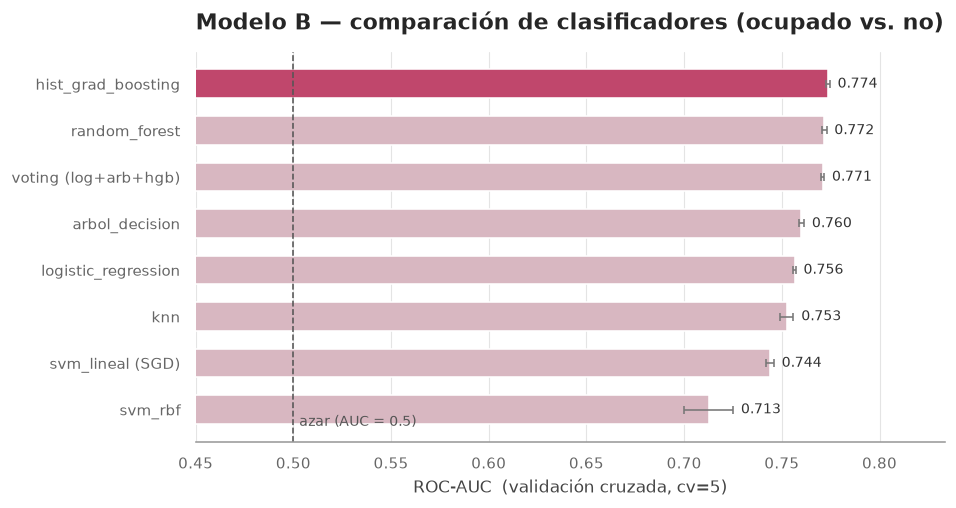

In [25]:
# --- Comparación visual de ROC-AUC (CV); la línea punteada marca el azar ---
c = res_clf[res_clf.modelo != "baseline (mayoría)"].sort_values("roc_auc").reset_index(drop=True)
fig, ax = plt.subplots(figsize=(8.5, 4.6))
colores = [MUJ if i == c["roc_auc"].idxmax() else "#D8B7C1" for i in c.index]
ax.barh(c.modelo, c.roc_auc, xerr=c["std"], color=colores, height=0.62,
        error_kw=dict(ecolor="#777", lw=1, capsize=2.5))
for i, (v, e) in enumerate(zip(c.roc_auc, c["std"])):
    ax.text(v + e + 0.004, i, f"{v:.3f}", va="center", fontsize=9, color="#333")
ax.grid(False, axis="y"); ax.grid(True, axis="x")
ax.axvline(0.5, ls="--", c="#555", lw=1)
ax.text(0.503, -0.42, "azar (AUC = 0.5)", fontsize=8.5, color="#555", va="bottom")
ax.set_xlim(0.45, c.roc_auc.max() + 0.06)
ax.set_xlabel("ROC-AUC  (validación cruzada, cv=5)")
ax.set_title("Modelo B — comparación de clasificadores (ocupado vs. no)")
plt.tight_layout(); plt.savefig(FIG / "modeloB_comparacion_auc.png", dpi=150); plt.show()


> 🧭 **Tuneo también el clasificador** con `GridSearchCV`, replicando la búsqueda del Modelo A (tasa de aprendizaje, número de iteraciones y complejidad de los árboles), esta vez optimizando **ROC-AUC** por validación cruzada dentro del entrenamiento. Todo el aparato interpretativo que sigue (dependencia parcial, SHAP, fairness, calibración) se apoya en este clasificador; interpretarlo con fineza exige que esté sometido al mismo nivel de optimización que el modelo de ingreso. AUC mide **discriminación** (qué tan bien ordena ocupados por encima de no-ocupados), no calibración: las probabilidades se evalúan y corrigen aparte, en la sección 12 (Clase 6).
>
> Si omitiera esta búsqueda, las conclusiones aguas abajo dependerían de hiperparámetros por defecto, arbitrarios para este problema; y si eligiera la grilla mirando el test, el ROC-AUC reportado sería optimista.

In [26]:
# --- Tuning del mejor modelo (HistGradientBoosting) con GridSearchCV, scoring ROC-AUC ---
grid_b = ({                                 # grilla completa (modo completo), análoga a la del Modelo A
    "model__learning_rate": [0.02, 0.05, 0.1],
    "model__max_iter": [200, 400],
    "model__max_leaf_nodes": [31, 63, 127],
} if P["grid_full"] else {                  # grilla mínima (modo rápido): 2 combos
    "model__learning_rate": [0.1],
    "model__max_iter": [200],
    "model__max_leaf_nodes": [31, 63],
})
gs_clf = GridSearchCV(
    Pipeline([("prep", build_prep(Xc_tr)), ("model", HistGradientBoostingClassifier(random_state=SEED))]),
    grid_b, cv=3, scoring="roc_auc", n_jobs=-1)
gs_clf.fit(Xc_tr, yc_tr)
print("Mejores hiperparámetros:", gs_clf.best_params_)
print(f"ROC-AUC (CV) con la mejor grilla: {gs_clf.best_score_:.3f}")

/Users/gv/projects/ceia_add/ML FIUBA/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Mejores hiperparámetros: {'model__learning_rate': 0.02, 'model__max_iter': 400, 'model__max_leaf_nodes': 63}
ROC-AUC (CV) con la mejor grilla: 0.774


> 🧭 Evalúo el clasificador ya tuneado (Gradient Boosting con la mejor grilla) **una sola vez** en el test reservado: reporto su ROC-AUC, el reporte de clasificación (precisión y recall por clase) y dibujo la **curva ROC**, que muestra el compromiso entre detectar ocupados y marcar falsos positivos a lo largo de todos los umbrales de decisión. La validación cruzada me sirvió para *elegir* modelo; el test reservado me da la medida **final e independiente** de cómo se comportaría con datos no vistos. Miro recall por clase además del AUC porque, con clases desbalanceadas, me interesa cuántos no-ocupados detecta realmente, no sólo el acierto global.
>
> Reportar el desempeño con los mismos datos usados para elegir y tunear el modelo daría cifras infladas; el test reservado evita ese autoengaño.

ROC-AUC en TEST: 0.773



              precision    recall  f1-score   support

  no ocupado       0.64      0.30      0.41     34227
     ocupado       0.78      0.94      0.85     92692

    accuracy                           0.77    126919
   macro avg       0.71      0.62      0.63    126919
weighted avg       0.74      0.77      0.73    126919



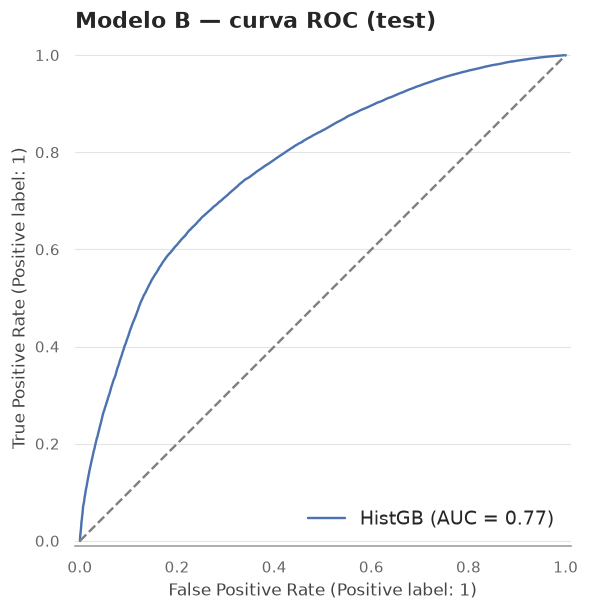

In [27]:
# --- Evaluación sobre test reservado con el mejor modelo ---
from sklearn.metrics import roc_auc_score, classification_report, RocCurveDisplay

best_clf = gs_clf.best_estimator_   # pipeline reentrenado con la mejor combinación de la grilla
proba_te = best_clf.predict_proba(Xc_te)[:, 1]
auc_te = roc_auc_score(yc_te, proba_te)
print(f"ROC-AUC en TEST: {auc_te:.3f}\n")
print(classification_report(yc_te, best_clf.predict(Xc_te),
                            target_names=["no ocupado", "ocupado"]))
fig, ax = plt.subplots(figsize=(5.5, 5.5))
RocCurveDisplay.from_predictions(yc_te, proba_te, ax=ax, name="HistGB")
ax.plot([0,1],[0,1], ls="--", c="gray"); ax.set_title("Modelo B — curva ROC (test)")
plt.tight_layout(); plt.savefig(FIG / "modeloB_roc.png", dpi=120); plt.show()

> 🧭 Calculo la **partial dependence** de la edad por sexo: tomo a las personas del test, les voy fijando la edad en cada valor de 35 a 64 (dejando todo lo demás como está) y promedio la probabilidad de empleo que predice el modelo. Obtengo así una curva 'probabilidad de estar ocupado vs. edad', separada para varones y mujeres. Es la forma de aislar el **efecto de la edad manteniendo constante el resto** (educación, región, año): respondo '¿cómo cambia la chance de empleo si sólo cambia la edad?'. Este gráfico es el resultado central, porque traduce un modelo complejo en una historia legible y prueba la hipótesis de penalización etaria neta (H1). Reporto la caída cruda 35→64 y, además, la caída en una **ventana alineada por la jubilación propia** (varones 40→64, mujeres 35→59: mismos 25 años, terminando en la víspera del retiro de cada sexo), para no mezclar la penalización etaria con el efecto institucional de que las mujeres de 60–64 ya puedan jubilarse.
>
> Sin controlar el resto de las variables, una simple curva de empleo por edad mezclaría el efecto edad con diferencias de composición (p. ej. que los mayores tengan otra educación), y no podría atribuir la caída a la edad en sí.

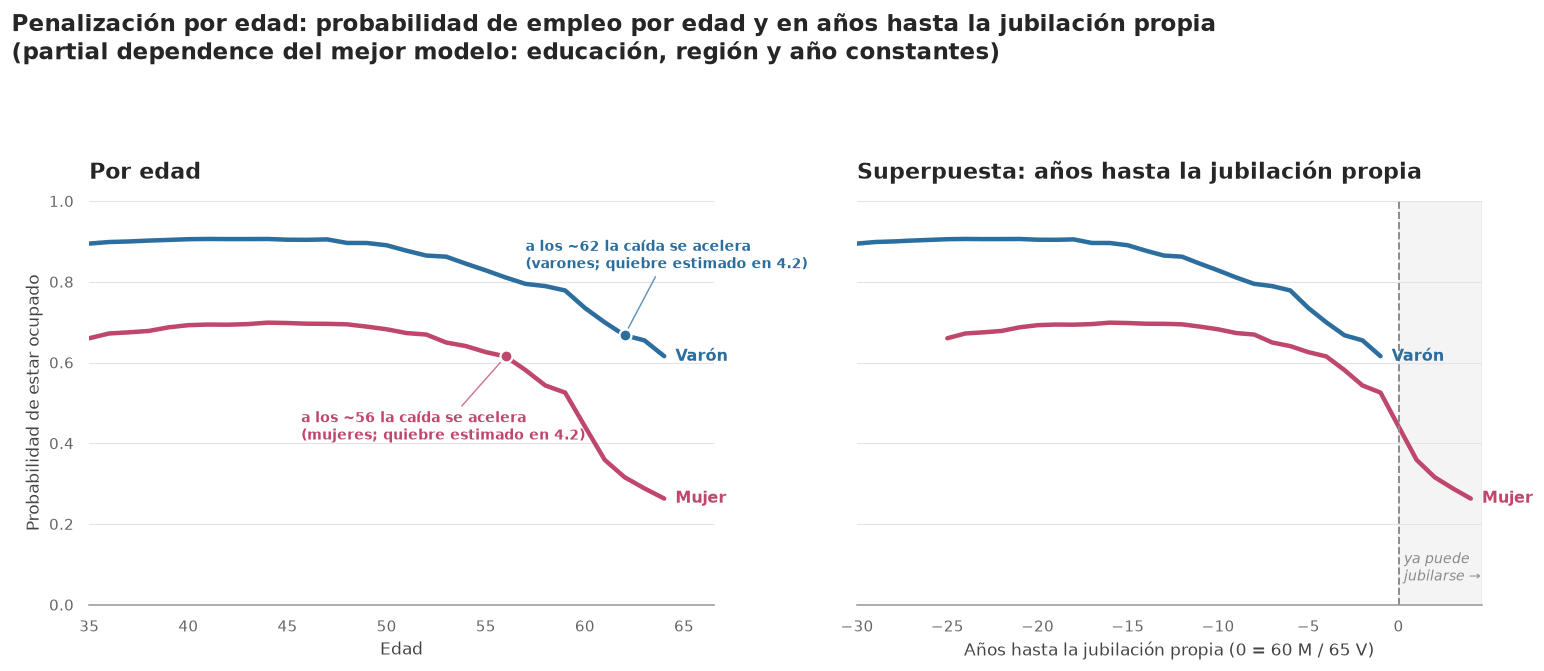

Varón : prob. empleo 35=0.89 → 64=0.62  (caída 28 pts)
Mujer : prob. empleo 35=0.66 → 64=0.26  (caída 40 pts)
Varón : ventana alineada 40→64 (víspera de su jubilación): 0.91 → 0.62  (caída 29 pts)
Mujer : ventana alineada 35→59 (víspera de su jubilación): 0.66 → 0.53  (caída 13 pts)


In [28]:
# --- Resultado central: penalización por edad (partial dependence de edad por sexo) ---
edades = np.arange(35, 65)
fig, ax = plt.subplots(1, 2, figsize=(13.5, 5.4), sharey=True)
caidas, probs_sexo = {}, {}
for sx, col in [("Varón", VAR), ("Mujer", MUJ)]:
    base = Xc_te[Xc_te.sexo == sx].copy()          # personas reales de ese sexo (test)
    # para cada edad: fijo esa edad en TODA la sub-muestra (lo demás intacto) y
    # promedio la prob. de empleo predicha -> efecto de la edad "todo lo demás constante"
    probs = np.array([best_clf.predict_proba(base.assign(edad=e))[:, 1].mean() for e in edades])
    ax[0].plot(edades, probs, color=col, lw=2.8)
    fin_de_linea(ax[0], 64, probs[-1], sx, col)
    k = BK[sx]["aceleracion"]                       # quiebre estimado en la sección 4.2
    if edades[0] <= k <= edades[-1]:
        marca_quiebre(ax[0], k, probs[k - edades[0]], col,
                      f"a los ~{k} la caída se acelera\n({'varones' if sx == 'Varón' else 'mujeres'}; quiebre estimado en 4.2)",
                      dx=(-62 if sx == "Varón" else -128), dy=(42 if sx == "Varón" else -52))
    # panel derecho: la MISMA curva, con el eje en años hasta la jubilación propia
    ts = edades - RET[sx]
    ax[1].plot(ts, probs, color=col, lw=2.8)
    fin_de_linea(ax[1], ts[-1], probs[-1], sx, col)
    caidas[sx] = (probs[0], probs[-1])              # prob. a los 35 y a los 64
    probs_sexo[sx] = probs
ax[1].axvspan(0, 4.6, color=GRIS, alpha=.09, zorder=0)
ax[1].axvline(0, ls="--", c=GRIS, lw=1.2)
ax[1].text(0.3, 0.06, "ya puede\njubilarse →", color=GRIS, fontsize=9, style="italic")
estilo_serie(ax[0], "Por edad", "Edad", "Probabilidad de estar ocupado")
estilo_serie(ax[1], "Superpuesta: años hasta la jubilación propia",
             "Años hasta la jubilación propia (0 = 60 M / 65 V)", "")
ax[0].set_ylim(0, 1); ax[0].set_xlim(35, 66.5); ax[1].set_xlim(-30, 4.6)
fig.suptitle("Penalización por edad: probabilidad de empleo por edad y en años hasta la jubilación propia\n"
             "(partial dependence del mejor modelo: educación, región y año constantes)",
             x=0.005, ha="left", y=1.08, fontsize=14.5, fontweight="semibold")
plt.tight_layout(); plt.savefig(FIG / "pdp_edad_empleo.png"); plt.show()

for sx, (p0, p1) in caidas.items():
    print(f"{sx:6}: prob. empleo 35={p0:.2f} → 64={p1:.2f}  (caída {100*(p0-p1):.0f} pts)")

# caída en la VENTANA ALINEADA por jubilación propia: mismos 25 años, hasta la víspera del retiro
caidas_alin = {}
for sx in ["Varón", "Mujer"]:
    a0, a1 = RET[sx] - 25, RET[sx] - 1                  # varón 40→64, mujer 35→59
    p0, p1 = probs_sexo[sx][a0 - 35], probs_sexo[sx][a1 - 35]
    caidas_alin[sx] = (p0, p1)
    print(f"{sx:6}: ventana alineada {a0}→{a1} (víspera de su jubilación): "
          f"{p0:.2f} → {p1:.2f}  (caída {100*(p0-p1):.0f} pts)")

In [29]:
# --- Lectura dinámica: AUC y caídas de probabilidad tomados de esta corrida ---
from IPython.display import Markdown
_cav = 100 * (caidas_alin['Varón'][0] - caidas_alin['Varón'][1])
_cam = 100 * (caidas_alin['Mujer'][0] - caidas_alin['Mujer'][1])
Markdown(f"""**Lectura.** El modelo de referencia (clase mayoritaria) presenta ROC-AUC = 0.5: no
discrimina entre ocupados y no-ocupados y su acierto se debe exclusivamente al
desbalance. El mejor modelo alcanza **ROC-AUC = {auc_te:.2f} en test**. Controlando
educación, región y año, la probabilidad de estar ocupado **disminuye con la edad en
ambos sexos** (35→64: varones {caidas['Varón'][0]:.2f} → {caidas['Varón'][1]:.2f}; mujeres
{caidas['Mujer'][0]:.2f} → {caidas['Mujer'][1]:.2f}). Dos precisiones, para no mezclar dimensiones:

1. **Penalización etaria (H1) — leer el panel derecho.** La comparación cruda 35→64 es
   **asimétrica** respecto de la jubilación: incluye mujeres de 60–64 ya jubilables y
   ningún varón en esa condición. El panel derecho superpone las curvas en **años hasta
   la jubilación propia**: en la ventana común que termina en la víspera del retiro
   (varones 40→64, mujeres 35→59) la caída es de **{_cav:.0f} pts en varones y {_cam:.0f} pts en
   mujeres** — a igual distancia del retiro, la pendiente masculina **no es menor**.
   Parte de la diferencia total refleja que la rampa masculina transcurre a edades
   mayores (llega hasta los 64): como edad y distancia al retiro son **colineales**
   dentro de cada sexo, la atribución fina entre ambos relojes no es identificable
   (véase la robustez de 4.2); lo firme es que la penalización etaria **no es menor en
   los varones**.
2. **Brecha por sexo (H2).** La curva femenina se sitúa **por debajo en todo el
   recorrido** — incluso a los 35–45, lejos de la jubilación. El modelo está
   aprendiendo la **brecha de participación** documentada en 4.1 (no una menor
   calificación, que está controlada); y, como aquélla, **no distingue** cuánto es
   oferta del hogar y cuánto demanda del mercado.""")

**Lectura.** El modelo de referencia (clase mayoritaria) presenta ROC-AUC = 0.5: no
discrimina entre ocupados y no-ocupados y su acierto se debe exclusivamente al
desbalance. El mejor modelo alcanza **ROC-AUC = 0.77 en test**. Controlando
educación, región y año, la probabilidad de estar ocupado **disminuye con la edad en
ambos sexos** (35→64: varones 0.89 → 0.62; mujeres
0.66 → 0.26). Dos precisiones, para no mezclar dimensiones:

1. **Penalización etaria (H1) — leer el panel derecho.** La comparación cruda 35→64 es
   **asimétrica** respecto de la jubilación: incluye mujeres de 60–64 ya jubilables y
   ningún varón en esa condición. El panel derecho superpone las curvas en **años hasta
   la jubilación propia**: en la ventana común que termina en la víspera del retiro
   (varones 40→64, mujeres 35→59) la caída es de **29 pts en varones y 13 pts en
   mujeres** — a igual distancia del retiro, la pendiente masculina **no es menor**.
   Parte de la diferencia total refleja que la rampa masculina transcurre a edades
   mayores (llega hasta los 64): como edad y distancia al retiro son **colineales**
   dentro de cada sexo, la atribución fina entre ambos relojes no es identificable
   (véase la robustez de 4.2); lo firme es que la penalización etaria **no es menor en
   los varones**.
2. **Brecha por sexo (H2).** La curva femenina se sitúa **por debajo en todo el
   recorrido** — incluso a los 35–45, lejos de la jubilación. El modelo está
   aprendiendo la **brecha de participación** documentada en 4.1 (no una menor
   calificación, que está controlada); y, como aquélla, **no distingue** cuánto es
   oferta del hogar y cuánto demanda del mercado.

### 6.1 Un árbol de decisión interpretable (reglas explícitas)

Los modelos de mayor AUC son de tipo *caja negra* (escasa interpretabilidad). Un
**árbol de decisión único** (Clase 4), con profundidad acotada, sacrifica algo de
desempeño a cambio de **reglas legibles**: cada hoja es una condición sobre edad,
educación y sexo. Permite *explicar* la penalización, además de predecirla.

> 🧭 Entreno un **árbol de decisión** poco profundo (máx. 3 niveles) y lo grafico. Un árbol es una serie de preguntas anidadas ('¿edad ≥ 56?', '¿tiene secundario?') que terminan en una probabilidad de empleo; al limitar su profundidad obtengo reglas legibles. Los modelos de mayor desempeño (ensambles) son cajas negras. Sacrifico algo de precisión a cambio de **interpretabilidad**: poder enunciar la penalización como una regla explícita ('mujer, 56+, sin secundario → baja probabilidad de empleo') es clave para comunicar y defender el resultado ante una audiencia no técnica.
>
> Sin acotar la profundidad, el árbol memorizaría ruido (sobreajuste) y dejaría de ser legible; sin un modelo interpretable, sólo tendría números de AUC difíciles de traducir en una conclusión accionable.

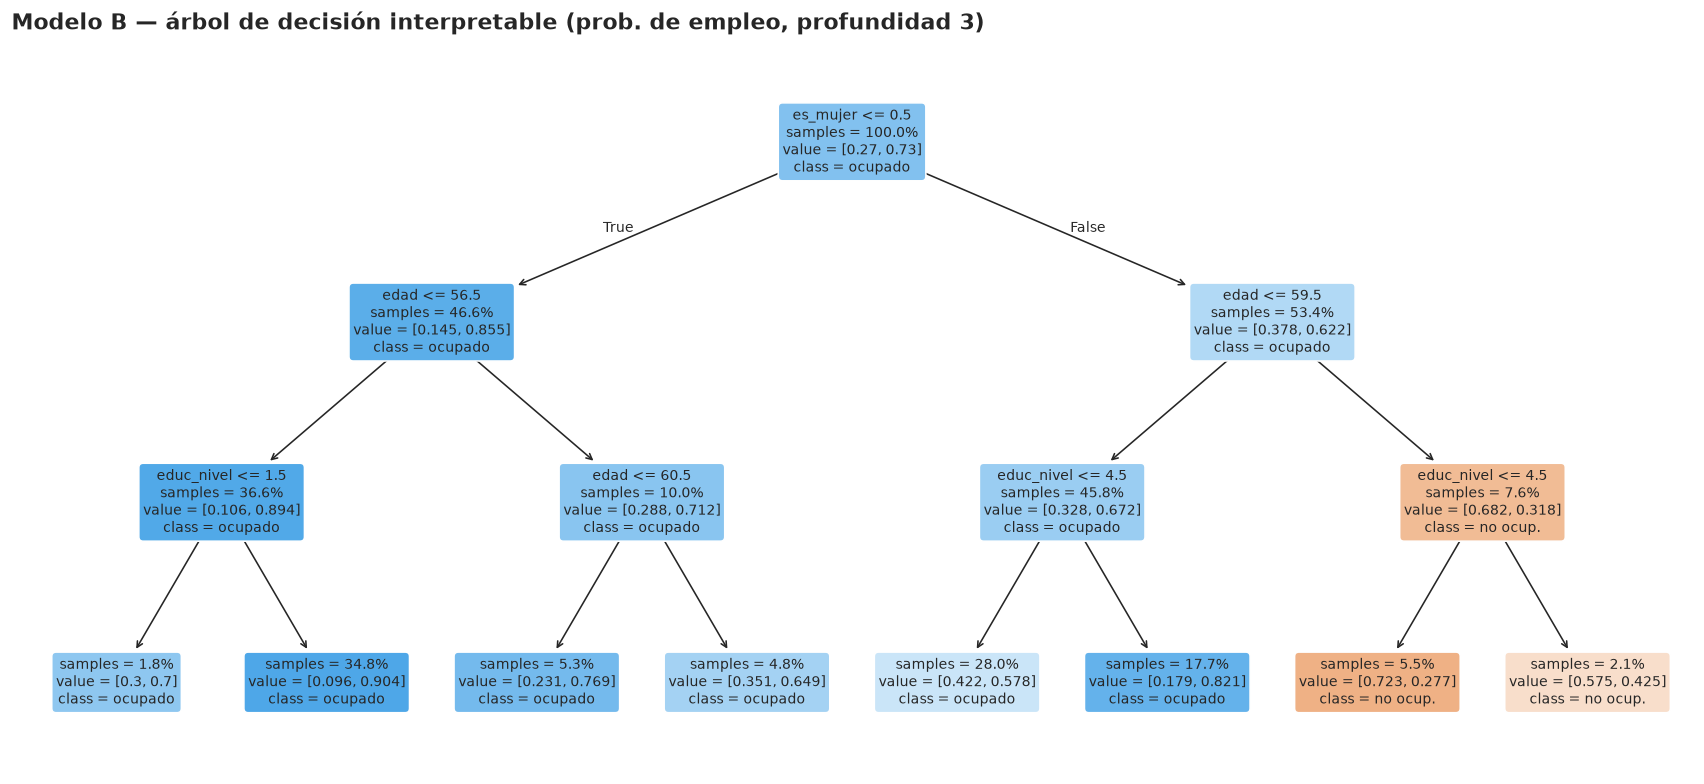

Regla 'mujer + 56+ + sin superior': 49,354 personas, prob. de empleo = 0.37
Referencia 'varón + <45'           : 93,345 personas, prob. de empleo = 0.91


In [30]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Codificación ordinal legible del nivel educativo (para que el árbol sea claro)
ED_ORDER = {"Sin instrucción":0, "Primario inc.":1, "Primario comp.":2,
            "Secundario inc.":3, "Secundario comp.":4, "Superior inc.":5,
            "Superior comp.":6, "Ns/Nr":np.nan}
# (corrección v2.2) El árbol se entrena SÓLO con el train, como el resto del pipeline
Xtree = pd.DataFrame({
    "edad":       Xc_tr["edad"].values,
    "es_mujer":   (Xc_tr["sexo"] == "Mujer").astype(int).values,
    "educ_nivel": Xc_tr["nivel_ed"].map(ED_ORDER).values,
    "anio":       Xc_tr["anio"].values,
}, index=Xc_tr.index).dropna()
ytree = yc_tr.loc[Xtree.index]

arbol = DecisionTreeClassifier(max_depth=3, min_samples_leaf=2000, random_state=SEED).fit(Xtree, ytree)
plt.figure(figsize=(15, 7))
plot_tree(arbol, feature_names=list(Xtree.columns), class_names=["no ocup.", "ocupado"],
          filled=True, rounded=True, impurity=False, proportion=True, fontsize=9)
plt.title("Modelo B — árbol de decisión interpretable (prob. de empleo, profundidad 3)")
plt.tight_layout(); plt.savefig(FIG / "modeloB_arbol.png", dpi=120); plt.show()

# Regla destacada: subgrupo con menor probabilidad de empleo.
# El corte de edad (56) es el quiebre estimado para mujeres en la sección 4.2, no un valor a priori.
edad_q = BK["Mujer"]["aceleracion"]
sub = Xtree.assign(ocupado=ytree)
regla = sub[(sub.es_mujer == 1) & (sub.edad >= edad_q) & (sub.educ_nivel <= 4)]
p_regla = regla.ocupado.mean()
print(f"Regla 'mujer + {edad_q}+ + sin superior': {len(regla):,} personas, "
      f"prob. de empleo = {p_regla:.2f}")
ref = sub[(sub.es_mujer == 0) & (sub.edad < 45)]
p_ref = ref.ocupado.mean()
print(f"Referencia 'varón + <45'           : {len(ref):,} personas, "
      f"prob. de empleo = {p_ref:.2f}")

In [31]:
# --- Lectura dinámica: regla y referencia tomadas de esta corrida ---
from IPython.display import Markdown
Markdown(f"""**Lectura.** El árbol confirma el patrón mediante reglas explícitas: los primeros
cortes corresponden a **edad** y a **sexo/educación**. El subgrupo *mujer, pasada la
edad de aceleración (~{edad_q}), sin estudios superiores* presenta una probabilidad de
empleo de **{p_regla:.2f}**, marcadamente inferior a la de la referencia *varón menor de
45* (**{p_ref:.2f}**): reproduce el perfil de exclusión postulado por la hipótesis, ahora
expresado como una regla explícita.""")


**Lectura.** El árbol confirma el patrón mediante reglas explícitas: los primeros
cortes corresponden a **edad** y a **sexo/educación**. El subgrupo *mujer, pasada la
edad de aceleración (~56), sin estudios superiores* presenta una probabilidad de
empleo de **0.37**, marcadamente inferior a la de la referencia *varón menor de
45* (**0.91**): reproduce el perfil de exclusión postulado por la hipótesis, ahora
expresado como una regla explícita.

## 7. Oaxaca–Blinder — descomposición de la brecha de ingreso por sexo

¿Cuánto de la brecha de ingreso entre varones y mujeres se explica por
diferencias de **características** (edad, educación, región) y cuánto queda como
parte **no explicada** (asociada a discriminación / efectos no observados)?
La descomposición de Oaxaca–Blinder (twofold) separa ambos componentes sobre el
**log del ingreso** de los ocupados, ponderando por `PONDIIO`.

> 🧭 Aplico la **descomposición de Oaxaca–Blinder**: ajusto una regresión del log-ingreso por separado para varones y para mujeres y, con eso, parto la brecha promedio en dos componentes: el **explicado** (diferencias en características observables: educación, edad, región) y el **no explicado** (lo que queda tras igualar esas características, atribuible a discriminación o factores no observados). La importancia por permutación dice que el sexo *pesa*, pero no cuánto de la brecha es composición y cuánto es trato desigual. Oaxaca–Blinder es el método **estándar en economía laboral** (Oaxaca 1973; Blinder 1973) para separar exactamente eso, y aporta el rigor econométrico que complementa al machine learning.
>
> Sin esta descomposición, no podría distinguir 'las mujeres ganan menos porque tienen otra calificación' de 'ganan menos a igual calificación'. Confundir ambas cosas llevaría a conclusiones de política equivocadas.

In [32]:
import statsmodels.formula.api as smf
import patsy

OB_FORMULA = "log_ing ~ edad + edad2 + C(nivel_ed) + C(region)"

def oaxaca_blinder(d, formula=OB_FORMULA):
    # Descomposición twofold (referencia: coeficientes de varones).
    # Devuelve (gap, explicado, no_explicado) sobre log-ingreso, ponderado por PONDIIO.
    d = d.dropna(subset=["log_ing", "edad", "nivel_ed", "region", "sexo", "PONDIIO"])
    dv, dm = d[d.sexo == "Varón"], d[d.sexo == "Mujer"]
    mod_v = smf.wls(formula, data=dv, weights=dv["PONDIIO"]).fit()
    mod_m = smf.wls(formula, data=dm, weights=dm["PONDIIO"]).fit()
    def medias(dd):
        X = patsy.dmatrix(formula.split("~")[1], dd, return_type="dataframe")
        return pd.Series(np.average(X, axis=0, weights=dd["PONDIIO"].values), index=X.columns)
    xb_v, xb_m = medias(dv), medias(dm)
    b_v = mod_v.params.reindex(xb_v.index).fillna(0.0)
    b_m = mod_m.params.reindex(xb_m.index).fillna(0.0)
    gap = float(np.average(dv["log_ing"], weights=dv["PONDIIO"])
                - np.average(dm["log_ing"], weights=dm["PONDIIO"]))
    explicado = float((xb_v - xb_m) @ b_v)       # dotación (características)
    no_explicado = float(xb_m @ (b_v - b_m))     # coeficientes (residual / no explicado)
    return gap, explicado, no_explicado

ob = ocup[ocup.edad.between(25, 70)].copy()
ob["region"] = ob["REGION"].map(REGION)
ob["log_ing"] = np.log(ob["ingreso_rel"])
ob["edad2"] = ob["edad"] ** 2

gap, explicado, no_explicado = oaxaca_blinder(ob)
print(f"Brecha de log-ingreso (Varón − Mujer): {gap:+.4f}  (~{100*(np.exp(gap)-1):+.1f}% en nivel)")
print(f"  • Explicado por características  : {explicado:+.4f}  ({100*explicado/gap:4.0f}% de la brecha)")
print(f"  • No explicado (residual)       : {no_explicado:+.4f}  ({100*no_explicado/gap:4.0f}% de la brecha)")

# IC 95% por BOOTSTRAP (remuestreo con reposición, base del bagging de la Clase 5)
# para la brecha bruta de log-ingreso, ponderado por PONDIIO
_bb = ob.dropna(subset=["log_ing", "PONDIIO"])
lv, wv = (_bb.loc[_bb.sexo == "Varón", c].to_numpy(float) for c in ["log_ing", "PONDIIO"])
lm, wm = (_bb.loc[_bb.sexo == "Mujer", c].to_numpy(float) for c in ["log_ing", "PONDIIO"])
rng = np.random.RandomState(SEED)
boots = np.empty(P["boot_reps"])
for b in range(P["boot_reps"]):
    iv = rng.randint(0, len(lv), len(lv)); im = rng.randint(0, len(lm), len(lm))
    boots[b] = np.average(lv[iv], weights=wv[iv]) - np.average(lm[im], weights=wm[im])
gap_ci = np.percentile(boots, [2.5, 97.5])
print(f"IC 95% bootstrap ({P['boot_reps']} rep.): [{gap_ci[0]:+.4f}, {gap_ci[1]:+.4f}] en log "
      f"→ [{100*(np.exp(gap_ci[0])-1):.1f}%, {100*(np.exp(gap_ci[1])-1):.1f}%] en nivel")

Brecha de log-ingreso (Varón − Mujer): +0.3944  (~+48.4% en nivel)
  • Explicado por características  : -0.1116  ( -28% de la brecha)
  • No explicado (residual)       : +0.5061  ( 128% de la brecha)


IC 95% bootstrap (1000 rep.): [+0.3861, +0.4035] en log → [47.1%, 49.7%] en nivel


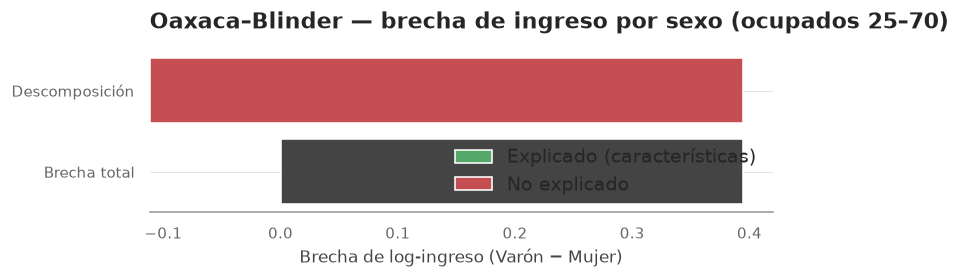

In [33]:
plt.figure(figsize=(7, 2.6))
plt.barh(["Brecha total"], [gap], color="#444")
plt.barh(["Descomposición"], [explicado], color="#55A868", label="Explicado (características)")
plt.barh(["Descomposición"], [no_explicado], left=[explicado], color="#C44E52", label="No explicado")
plt.xlabel("Brecha de log-ingreso (Varón − Mujer)")
plt.title("Oaxaca–Blinder — brecha de ingreso por sexo (ocupados 25–70)")
plt.legend(loc="lower right"); plt.tight_layout()
plt.savefig(FIG / "oaxaca_sexo.png", dpi=120); plt.show()

In [34]:
# --- Lectura dinámica: componentes de Oaxaca–Blinder de esta corrida ---
from IPython.display import Markdown
_pe, _pn = 100 * explicado / gap, 100 * no_explicado / gap
Markdown(f"""**Lectura.** El componente **explicado por las características resulta negativo**
(≈ {_pe:.0f} % de la brecha). En otros términos, según sus credenciales observables
(educación, región, edad) las mujeres ocupadas deberían percibir ingresos
ligeramente superiores a los de los varones; sin embargo, perciben ingresos
sensiblemente **menores**. La totalidad de la brecha —e incluso una fracción
adicional— se concentra en el componente **no explicado** ({_pn:.0f} %): a igual edad,
educación y región, persiste una diferencia de ingreso por sexo de ~{100 * (np.exp(gap) - 1):.0f} % en nivel
(IC 95 % bootstrap: {100 * (np.exp(gap_ci[0]) - 1):.0f}–{100 * (np.exp(gap_ci[1]) - 1):.0f} %) que las variables observables no justifican. Este resultado constituye
evidencia robusta a favor de la hipótesis de penalización por sexo y es coherente con
el peso no nulo del sexo en el Modelo A.""")


**Lectura.** El componente **explicado por las características resulta negativo**
(≈ -28 % de la brecha). En otros términos, según sus credenciales observables
(educación, región, edad) las mujeres ocupadas deberían percibir ingresos
ligeramente superiores a los de los varones; sin embargo, perciben ingresos
sensiblemente **menores**. La totalidad de la brecha —e incluso una fracción
adicional— se concentra en el componente **no explicado** (128 %): a igual edad,
educación y región, persiste una diferencia de ingreso por sexo de ~48 % en nivel
(IC 95 % bootstrap: 47–50 %) que las variables observables no justifican. Este resultado constituye
evidencia robusta a favor de la hipótesis de penalización por sexo y es coherente con
el peso no nulo del sexo en el Modelo A.

## 8. Fairness — auditoría del clasificador de empleo

Aunque el clasificador no use el sexo como "etiqueta protegida" de forma
explícita, puede producir predicciones con disparidades por sexo o por franja
etaria. Usamos `fairlearn` para medir **paridad demográfica** (igualdad de tasa
de selección) y **equalized odds** (igualdad de TPR/FPR) sobre el test.

Esta sección constituye una **auditoría del modelo, no una prueba causal de
discriminación**: las métricas cuantifican disparidades en las predicciones del
clasificador sobre el test; los mecanismos que podrían generarlas se discuten con
la evidencia de las secciones 4, 7 y 10.

> 🧭 **Audito el clasificador de empleo con métricas de fairness** (`fairlearn`): comparo, por sexo y por franja etaria, la tasa de selección (a quién predice como ocupado), la exactitud y los errores (TPR/FPR), y calculo brechas como *demographic parity* y *equalized odds*. Un modelo puede tener buen AUC global y aun así tratar muy distinto a cada grupo. Auditar disparidades es una práctica responsable y, en este trabajo, además **mide el propio fenómeno**: si el modelo asigna sistemáticamente menos chance de empleo a mujeres y mayores, está cuantificando la exclusión presente en los datos.
>
> Si no auditara por grupo, podría presentar un modelo 'bueno en promedio' que en la práctica perjudica a un colectivo; y si alguien lo usara para decisiones de contratación, perpetuaría esa disparidad sin que nadie lo advirtiera.

In [35]:
from fairlearn.metrics import (MetricFrame, selection_rate, true_positive_rate,
                               false_positive_rate, demographic_parity_difference,
                               equalized_odds_difference)
from sklearn.metrics import accuracy_score

y_pred = best_clf.predict(Xc_te)
edad_te = Xc_te["edad"]
franja = pd.cut(edad_te, bins=[35,50,60,65], labels=["35-49","50-59","60-64"], right=False)

for nombre, sf in [("sexo", Xc_te["sexo"]), ("franja etaria", franja)]:
    mf = MetricFrame(
        metrics={"tasa_selección (ocupado)": selection_rate,
                 "accuracy": accuracy_score,
                 "TPR": true_positive_rate, "FPR": false_positive_rate},
        y_true=yc_te, y_pred=y_pred, sensitive_features=sf)
    print(f"\n=== Por {nombre} ===")
    print(mf.by_group.round(3).to_string())
    print(f"  Demographic parity diff : {demographic_parity_difference(yc_te, y_pred, sensitive_features=sf):.3f}")
    print(f"  Equalized odds diff     : {equalized_odds_difference(yc_te, y_pred, sensitive_features=sf):.3f}")


=== Por sexo ===
       tasa_selección (ocupado)  accuracy   TPR   FPR
sexo                                                 
Mujer                     0.767     0.686 0.865 0.606
Varón                     0.993     0.857 0.996 0.974
  Demographic parity diff : 0.226


  Equalized odds diff     : 0.367



=== Por franja etaria ===
       tasa_selección (ocupado)  accuracy   TPR   FPR
edad                                                 
35-49                     0.967     0.806 0.983 0.902
50-59                     0.884     0.731 0.930 0.768
60-64                     0.459     0.677 0.643 0.291
  Demographic parity diff : 0.508


  Equalized odds diff     : 0.611


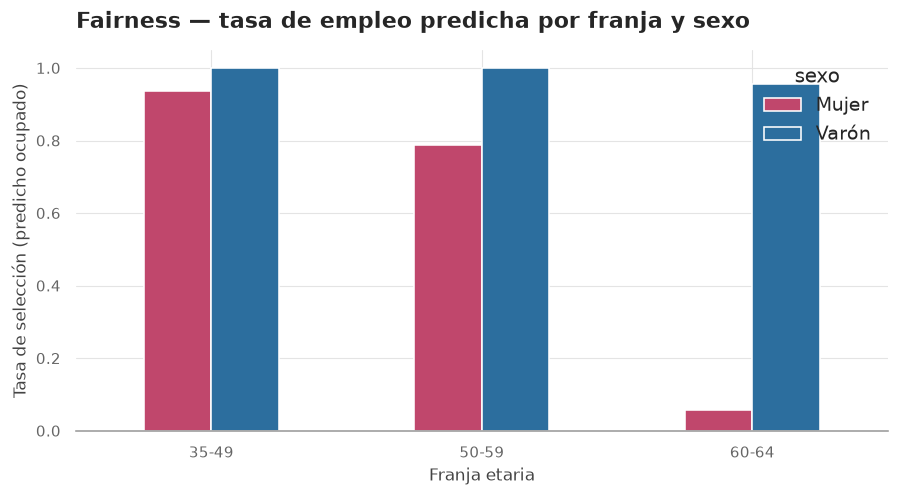

In [36]:
# Visual: tasa de selección (prob. de ser predicho 'ocupado') por franja y sexo
sr = (pd.DataFrame({"franja": franja.values, "sexo": Xc_te["sexo"].values, "pred": y_pred})
      .groupby(["franja", "sexo"], observed=True)["pred"].mean().unstack())
ax = sr.plot(kind="bar", figsize=(8, 4.5), color={"Varón": VAR, "Mujer": MUJ})
ax.set_ylabel("Tasa de selección (predicho ocupado)"); ax.set_xlabel("Franja etaria")
ax.set_title("Fairness — tasa de empleo predicha por franja y sexo")
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig(FIG / "fairness_seleccion.png", dpi=120); plt.show()

**Lectura.** Las disparidades en la tasa de selección y en TPR/FPR por sexo y, en
particular, por **franja etaria**, indican que el modelo reproduce el patrón de
exclusión presente en los datos; su utilización para automatizar decisiones de
contratación podría perpetuar dichas disparidades. La lectura por **sexo** debe
hacerse junto con la sección 4.1: la menor tasa de selección femenina refleja sobre
todo la **brecha de participación** (oferta y demanda mezcladas) y no constituye, por
sí sola, evidencia de discriminación del mercado. La disparidad por **franja etaria**,
en cambio, sí expresa la exclusión asociada a la edad (H1), que afecta a ambos sexos.

## 9. Evolución temporal de la brecha (2016–2024)

La EPH abarca **nueve años**, lo que permite analizar no sólo *si* existe la
penalización sino *si se incrementó o se redujo* a lo largo del tiempo. Se estiman,
año a año y de forma ponderada, (a) la **brecha de ingreso por sexo**, (b) la
**penalización de empleo por edad** (caída del empleo de la franja 60–64 respecto de
la meseta madura 45–54) y (c) la descomposición de **Oaxaca–Blinder por año**
(evolución del componente *no explicado*).

> 🧭 Repito los cálculos clave **año por año** (2016–2024): la brecha de ingreso por sexo, la penalización de empleo por edad (cuánto cae el empleo de 60–64 respecto de 45–54) y la descomposición de Oaxaca, para graficar su evolución temporal. La EPH cubre nueve años: aprovecho esa dimensión —lo más distintivo del dataset— para responder no sólo *si* existe la penalización, sino *si se agrava o se atenúa* con el tiempo. Que el componente no explicado se mantenga alto en todo el período es lo que permite afirmar que el fenómeno es **estructural** y no de un año puntual.
>
> Si mirara sólo el promedio 2016–2024, no podría distinguir un problema estructural de uno coyuntural (p. ej. atribuir a 'la economía' algo que en realidad persiste), y un valor atípico como 2020 (pandemia) podría distorsionar la lectura agregada.

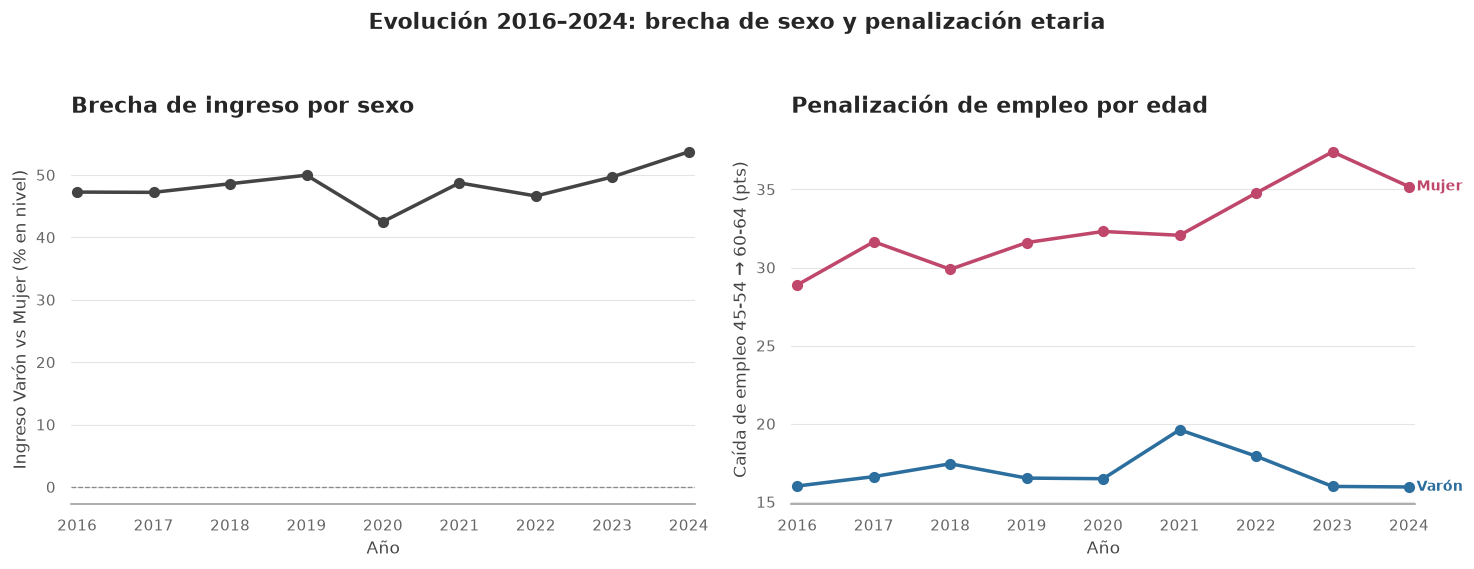

Brecha de ingreso por sexo (% en nivel) por año:
anio
2016   47.300
2017   47.200
2018   48.600
2019   50.000
2020   42.500
2021   48.700
2022   46.600
2023   49.700
2024   53.700


In [37]:
anios = sorted(df.anio.unique())

# (a) Brecha de ingreso por sexo (log), ponderada por PONDIIO, por año
rows = []
for a in anios:
    s = ocup[(ocup.anio == a) & ocup.edad.between(25, 70)]
    mv = np.average(np.log(s.loc[s.sexo=="Varón","ingreso_rel"]), weights=s.loc[s.sexo=="Varón","PONDIIO"])
    mm = np.average(np.log(s.loc[s.sexo=="Mujer","ingreso_rel"]), weights=s.loc[s.sexo=="Mujer","PONDIIO"])
    rows.append((a, mv - mm))
brecha_ing = pd.DataFrame(rows, columns=["anio", "brecha_log"]).set_index("anio")

# (b) Penalización de empleo por edad: empleo(45-54) − empleo(60-64), por sexo y año.
# El contraste compara la meseta madura con la franja ya en descenso acelerado
# (cortes alineados con los quiebres estimados en 4.2, no con un "58" a priori).
def emp_rate(d):
    return 100 * d.loc[d.ESTADO==1, "PONDERA"].sum() / d["PONDERA"].sum()
act = df[df.ESTADO.isin([1,2,3])]
rows = []
for a in anios:
    for sx in ["Varón", "Mujer"]:
        sub = act[(act.anio == a) & (act.sexo == sx)]
        pen = emp_rate(sub[sub.edad.between(45,54)]) - emp_rate(sub[sub.edad.between(60,64)])
        rows.append((a, sx, pen))
pen_emp = pd.DataFrame(rows, columns=["anio","sexo","penal"]).pivot(index="anio", columns="sexo", values="penal")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
ax[0].plot(brecha_ing.index, 100*(np.exp(brecha_ing.brecha_log)-1), "o-", color="#444",
           lw=2.2, ms=6); ax[0].axhline(0, c=GRIS, lw=.8, ls="--")
estilo_serie(ax[0], "Brecha de ingreso por sexo", "Año", "Ingreso Varón vs Mujer (% en nivel)")
for sx, col in [("Varón", VAR), ("Mujer", MUJ)]:
    ax[1].plot(pen_emp.index, pen_emp[sx], "o-", color=col, lw=2.2, ms=6)
    ax[1].text(pen_emp.index[-1]+0.1, pen_emp[sx].iloc[-1], sx, color=col, va="center",
               fontweight="bold", fontsize=9)
estilo_serie(ax[1], "Penalización de empleo por edad", "Año", "Caída de empleo 45-54 → 60-64 (pts)")
fig.suptitle("Evolución 2016–2024: brecha de sexo y penalización etaria",
             y=1.03, fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig(FIG / "temporal_brechas.png"); plt.show()
print("Brecha de ingreso por sexo (% en nivel) por año:")
print((100*(np.exp(brecha_ing.brecha_log)-1)).round(1).to_string())

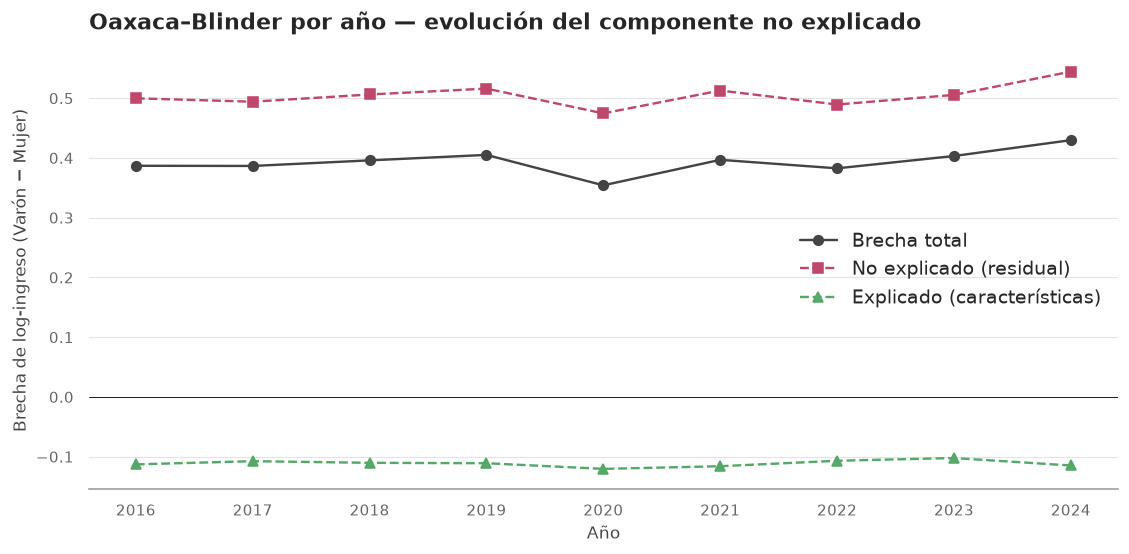

       gap  explicado  no_explicado
anio                               
2016 0.387     -0.113         0.500
2017 0.387     -0.108         0.494
2018 0.396     -0.110         0.506
2019 0.405     -0.111         0.516
2020 0.354     -0.120         0.475
2021 0.397     -0.116         0.513
2022 0.383     -0.107         0.490
2023 0.403     -0.102         0.506
2024 0.430     -0.115         0.545


In [38]:
# (c) Oaxaca–Blinder por año (reutiliza oaxaca_blinder de la sección 7)
rows = []
for a in anios:
    g, e, ne = oaxaca_blinder(ob[ob.anio == a])
    rows.append((a, g, e, ne))
oax_t = pd.DataFrame(rows, columns=["anio","gap","explicado","no_explicado"]).set_index("anio")

plt.figure(figsize=(10, 5))
plt.plot(oax_t.index, oax_t.gap, "o-", color="#444", label="Brecha total")
plt.plot(oax_t.index, oax_t.no_explicado, "s--", color=MUJ, label="No explicado (residual)")
plt.plot(oax_t.index, oax_t.explicado, "^--", color="#55A868", label="Explicado (características)")
plt.axhline(0, c="k", lw=.6); plt.xlabel("Año")
plt.ylabel("Brecha de log-ingreso (Varón − Mujer)")
plt.title("Oaxaca–Blinder por año — evolución del componente no explicado")
plt.legend(); plt.tight_layout(); plt.savefig(FIG / "oaxaca_temporal.png", dpi=120); plt.show()
print(oax_t.round(3).to_string())

**Lectura.** La descomposición temporal indica que el componente **no explicado**
de la brecha de ingreso por sexo **permanece elevado a lo largo de todo el período**
(no constituye un artefacto de un año particular), y que la penalización de empleo en
la franja de mayor edad (60–64) se mantiene sistemáticamente **mayor en mujeres**. El año **2020**
se comporta como valor atípico, asociado a la contracción del empleo durante la
pandemia; corresponde interpretar la tendencia y no ese punto aislado. El resultado
es consistente con un carácter **estructural** —y no coyuntural— de la penalización
por edad y sexo a lo largo de casi una década.

## 10. Interpretabilidad con SHAP

La importancia por permutación (sección 5) cuantifica *cuánto* pondera cada
variable en promedio; **SHAP** (SHapley Additive exPlanations; *Lundberg & Lee,
2017, "A Unified Approach to Interpreting Model Predictions", NeurIPS*) distribuye
cada predicción individual entre las variables, lo que permite identificar además la
**dirección** del efecto y su variación entre individuos. Se trata de una técnica no
abordada en clase, por lo que se la referencia explícitamente. SHAP se calcula sobre
un **RandomForest** (compatible con `TreeExplainer`) y una **muestra** de casos para
acotar el costo computacional (1 000 en modo rápido, 5 000 en completo).

> 🧭 Calculo valores **SHAP** sobre un **Random Forest** entrenado con los mismos datos —proxy del mejor modelo: `TreeExplainer` es exacto y eficiente en bosques, y lo que interesa aquí es la **dirección y forma** de los efectos, no el ranking fino—. SHAP reparte cada predicción individual entre las variables, indicando cuánto y en qué dirección empujó cada una. Muestro un resumen global (qué variables pesan y hacia dónde) y el efecto de la edad caso por caso. La permutación da una importancia *promedio*; SHAP agrega el detalle **individual y la dirección** del efecto (p. ej. que la edad alta empuja hacia 'no-ocupado' y que ese empuje se acelera pasados los ~55). Es una técnica reconocida (Lundberg & Lee, 2017) y, al coincidir con permutación y Oaxaca, refuerza la conclusión desde un tercer ángulo independiente.
>
> Quedarme sólo con una importancia promedio ocultaría la **forma** del efecto (lineal vs. acelerado) y su signo; podría, por ejemplo, no notar que el castigo etario se dispara recién a partir de cierta edad.

SHAP — Modelo B (empleo): RandomForest, muestra de 5,000 casos de test.


/var/folders/_w/kfsqkshn4gn5vxychd06znm40000gn/T/ipykernel_84514/3476213803.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, Xs, show=False, max_display=12)


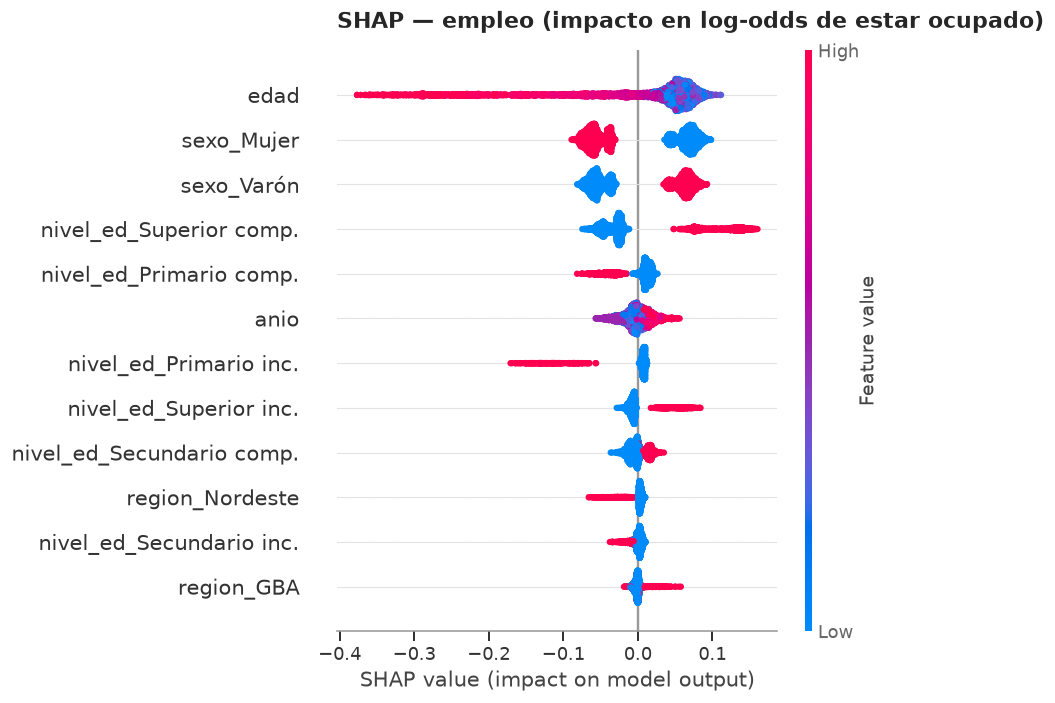

In [39]:
import shap

def shap_summary(Xtr, ytr, Xte, titulo, fname, task):
    prep = build_prep(Xtr); Xtr_e = prep.fit_transform(Xtr)
    names = [n.split("__", 1)[-1] for n in prep.get_feature_names_out()]
    Modelo = RandomForestClassifier if task == "clf" else RandomForestRegressor
    m = Modelo(n_estimators=200, min_samples_leaf=50, n_jobs=-1, random_state=SEED).fit(Xtr_e, ytr)
    Xs = pd.DataFrame(prep.transform(Xte.sample(min(P["n_shap"], len(Xte)), random_state=SEED)), columns=names)
    sv = shap.TreeExplainer(m).shap_values(Xs, check_additivity=False)
    if isinstance(sv, list):                 # API antigua: lista por clase
        sv = sv[1]
    elif getattr(sv, "ndim", 2) == 3:        # API nueva: (n, features, clases)
        sv = sv[:, :, 1]
    shap.summary_plot(sv, Xs, show=False, max_display=12)
    plt.title(titulo); plt.tight_layout()
    plt.savefig(FIG / fname, dpi=120, bbox_inches="tight"); plt.show()
    return sv, Xs

print(f"SHAP — Modelo B (empleo): RandomForest, muestra de {P['n_shap']:,} casos de test.")
sv_clf, Xs_clf = shap_summary(Xc_tr, yc_tr, Xc_te,
                              "SHAP — empleo (impacto en log-odds de estar ocupado)",
                              "shap_empleo.png", "clf")

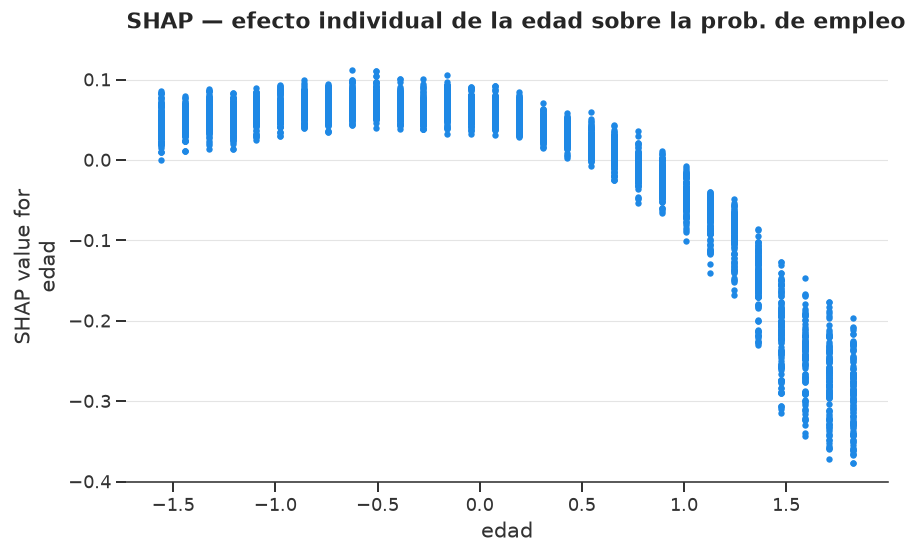

SHAP — Modelo A (ingreso): RandomForest, muestra de 5,000 casos de test.


/var/folders/_w/kfsqkshn4gn5vxychd06znm40000gn/T/ipykernel_84514/3476213803.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, Xs, show=False, max_display=12)


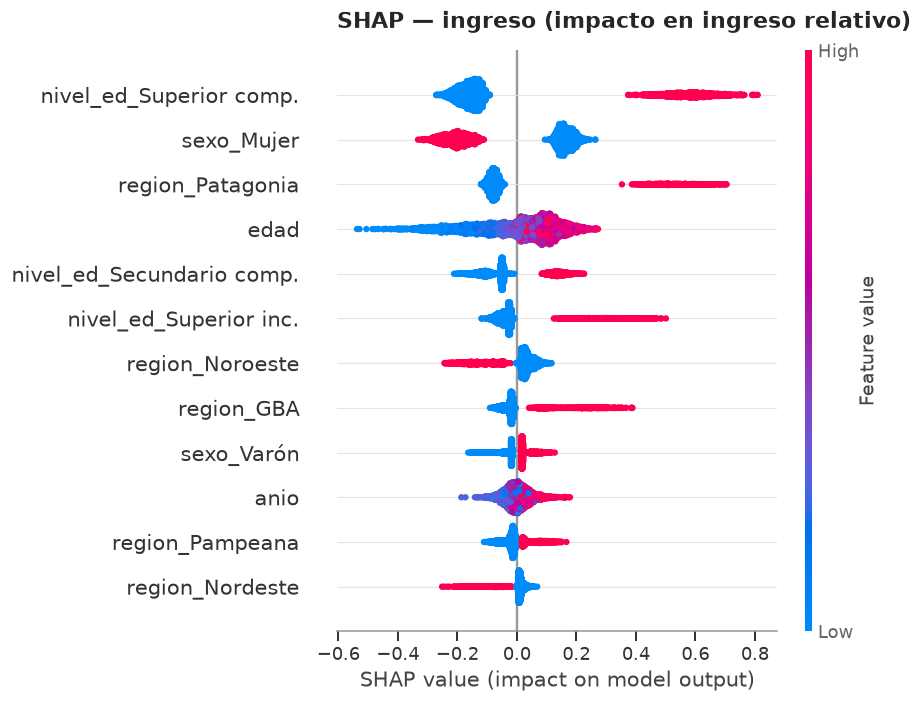

In [40]:
# Efecto INDIVIDUAL de la edad sobre la probabilidad de empleo (dependence plot)
shap.dependence_plot("edad", sv_clf, Xs_clf, interaction_index=None, show=False)
fig = plt.gcf(); fig.set_size_inches(8, 5)
plt.title("SHAP — efecto individual de la edad sobre la prob. de empleo")
plt.tight_layout(); plt.savefig(FIG / "shap_dependence_edad.png", dpi=120, bbox_inches="tight"); plt.show()

print(f"SHAP — Modelo A (ingreso): RandomForest, muestra de {P['n_shap']:,} casos de test.")
sv_reg, Xs_reg = shap_summary(Xr_tr, yr_tr, Xr_te,
                              "SHAP — ingreso (impacto en ingreso relativo)",
                              "shap_ingreso.png", "reg")

**Lectura.** El *beeswarm* del modelo de empleo complementa los resultados previos:
los **valores altos de edad desplazan la predicción hacia 'no-ocupado'** y la
condición de **mujer** presenta un aporte negativo sistemático. El *dependence plot*
evidencia que el efecto de la edad **se acelera pasada la mitad de la cincuentena (consistente con el quiebre estimado en la sección 4.2)**, con un
comportamiento no lineal. En el modelo de ingreso, SHAP confirma el predominio de la
educación y la región, en tanto el sexo desplaza la predicción de forma consistente.
Los resultados de SHAP, la importancia por permutación y Oaxaca–Blinder coinciden:
tres enfoques independientes conducen a la misma conclusión.

## 11. Segmentación de trabajadores (clustering no supervisado)

Hasta el momento se emplearon modelos supervisados. A continuación se examina, **sin
etiquetas**, si la población 35–64 se organiza en grupos naturales. Para que el
resultado **no sea tautológico**, la segmentación utiliza **sólo rasgos
estructurales de capital humano**
—**edad** y **nivel educativo**— y **dejamos afuera el estado de empleo y el
ingreso**: si los incluyéramos, k-means se limitaría a redescubrir "ocupado vs.
no-ocupado". *(La **región**, también estructural, se reserva para el perfilado: en
distancia euclidiana su codificación one-hot domina la métrica y sólo reproduce la
geografía, tapando la estructura etaria/educativa que nos interesa. La calificación
de la tarea `PP04D` se omite: sólo existe para quienes ya trabajan, así que
reintroduciría el sesgo de empleo.)* Recién **después** perfilamos cada cluster con
las variables de resultado (empleo, sexo, ingreso) para ver si alguno combina, de
forma **emergente**, edad alta y baja inserción laboral. Elegimos *k* combinando
**codo** (suma de cuadrados intra-cluster) e **índice de la silueta**, ambos
material de la **Clase 7**; la misma clase presenta el clustering **jerárquico** y
las mezclas gaussianas (**GMM**), que mencionamos como alternativas conceptuales
(segmentación anidada / blanda).

> 🧭 Aplico **k-means**, un método **no supervisado** (sin etiquetas) que agrupa a las personas en *k* clusters según su parecido. Las agrupo usando sólo edad y nivel educativo, elijo el número de clusters *k* con dos criterios (el 'codo' de la inercia y el coeficiente *silhouette*) y recién después describo cada grupo con variables de resultado (empleo, sexo, ingreso) que **no** usé para agrupar. Quiero ver si la estructura de 'mayores excluidos' **emerge sola** de los datos, sin que yo la imponga. Por eso agrupo sólo con rasgos estructurales y dejo afuera el empleo: si lo incluyera, k-means se limitaría a redescubrir 'ocupado vs. no-ocupado' (una tautología). Que un cluster de mayor edad tenga, por separado, baja inserción, es evidencia independiente de los modelos supervisados.
>
> Si clusterizara incluyendo el empleo o el ingreso, el resultado sería circular y sin valor. Y sin estandarizar o sin elegir *k* con criterio, obtendría grupos arbitrarios difíciles de interpretar.

Población a segmentar (35–64): 634,593 filas
Variables de clustering (estructurales): ['edad', 'educ_nivel']


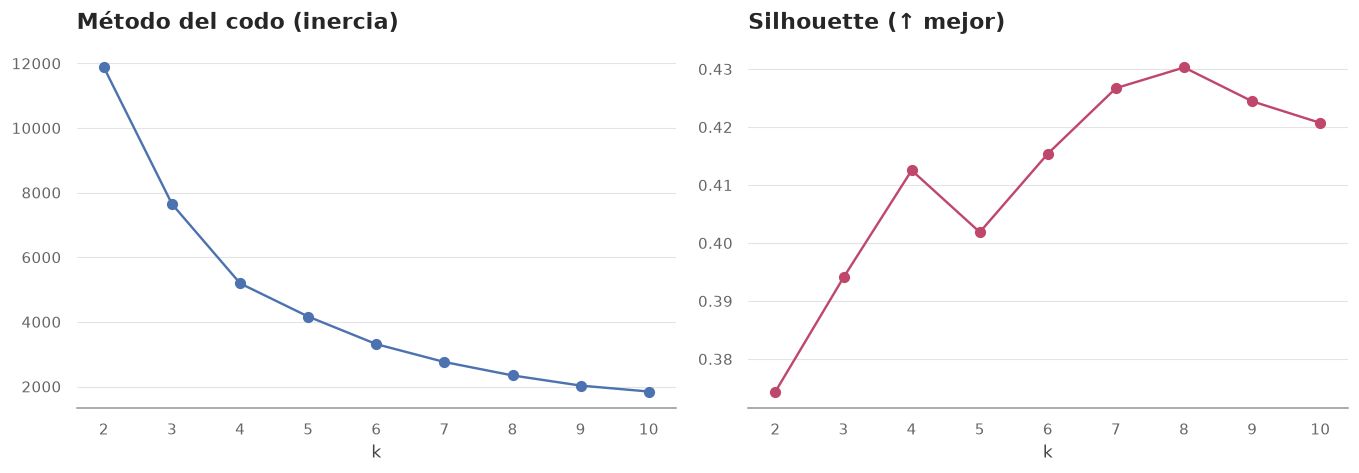

k elegido (máx. silhouette): 8


In [41]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ED_ORDER = {"Sin instrucción":0, "Primario inc.":1, "Primario comp.":2,
            "Secundario inc.":3, "Secundario comp.":4, "Superior inc.":5,
            "Superior comp.":6, "Ns/Nr":np.nan}
clu = df[df.ESTADO.isin([1,2,3]) & df.edad.between(35,64)].copy()
clu["educ_nivel"] = clu.nivel_ed.map(ED_ORDER)
clu["region"]     = clu.REGION.map(REGION)

# (corrección v2.1) Rasgos ESTRUCTURALES de capital humano: edad y nivel educativo.
# SIN empleo ni ingreso (serían el resultado → tautología). Región queda para el
# perfilado (one-hot domina la distancia y sólo reproduce la geografía); PP04D se
# omite (sólo existe para ocupados).
X_struct = clu[["edad", "educ_nivel"]].dropna()
Z = StandardScaler().fit_transform(X_struct)
print(f"Población a segmentar (35–64): {len(X_struct):,} filas")
print("Variables de clustering (estructurales):", list(X_struct.columns))

# Selección de k: codo + silhouette (silhouette sobre muestra de 10k por costo O(n²))
rng = np.random.RandomState(SEED)
samp = rng.choice(len(Z), min(10_000, len(Z)), replace=False)
ks = range(2, 11); inercia = []; sil = []   # rango ampliado: antes el máx. de silhouette caía en el borde
for k in ks:
    km = KMeans(n_clusters=k, n_init=P["kmeans_ninit"], random_state=SEED).fit(Z[samp])
    inercia.append(km.inertia_); sil.append(silhouette_score(Z[samp], km.labels_))
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
ax[0].plot(list(ks), inercia, "o-"); ax[0].set_title("Método del codo (inercia)"); ax[0].set_xlabel("k")
ax[1].plot(list(ks), sil, "o-", color=MUJ); ax[1].set_title("Silhouette (↑ mejor)"); ax[1].set_xlabel("k")
plt.tight_layout(); plt.savefig(FIG / "clustering_k.png", dpi=120); plt.show()
k_opt = list(ks)[int(np.argmax(sil))]
print("k elegido (máx. silhouette):", k_opt)

Perfil de los clusters (ordenados por edad; resultado NO usado para clusterizar):
              n   edad  educ_nivel  pct_ocupado  pct_mujer  ingreso_rel_ocup  % pobl.
cluster                                                                              
7         81176 38.940       5.650        0.880      0.600             1.620   12.790
2        104877 38.940       3.660        0.780      0.490             1.160   16.530
4         69941 43.080       1.750        0.680      0.470             0.880   11.020
1         72959 48.210       5.710        0.880      0.600             1.820   11.500
3         91430 48.240       3.630        0.770      0.500             1.230   14.410
0         82573 57.810       1.740        0.530      0.530             0.890   13.010
6         55701 58.630       5.750        0.690      0.590             1.970    8.780
5         75936 58.760       3.640        0.590      0.530             1.240   11.970

→ EMERGE un cluster de mayor edad con menor inserción: #5

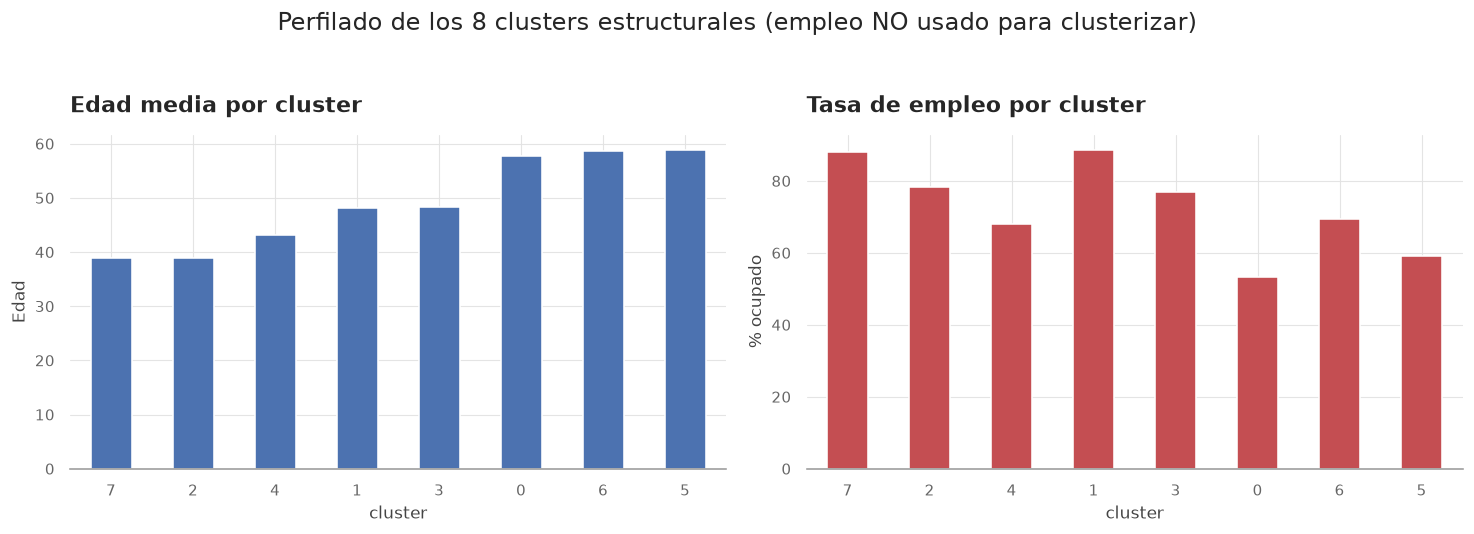

In [42]:
km = KMeans(n_clusters=k_opt, n_init=P["kmeans_ninit"], random_state=SEED).fit(Z)

# Perfilado: las variables de resultado (empleo, sexo, ingreso) NO entraron al
# clustering; las usamos sólo para describir los grupos hallados.
prof = clu.loc[X_struct.index].copy()
prof["cluster"]     = km.labels_
prof["ocupado"]     = (prof.ESTADO == 1).astype(int)
prof["es_mujer"]    = (prof.sexo == "Mujer").astype(int)
prof["ingreso_rel"] = ocup["ingreso_rel"].reindex(prof.index)   # NaN si no ocupado
perfil = prof.groupby("cluster").agg(
    n=("edad","size"), edad=("edad","mean"), educ_nivel=("educ_nivel","mean"),
    pct_ocupado=("ocupado","mean"), pct_mujer=("es_mujer","mean"),
    ingreso_rel_ocup=("ingreso_rel","mean")).sort_values("edad")
perfil["% pobl."] = 100 * perfil["n"] / perfil["n"].sum()
print("Perfil de los clusters (ordenados por edad; resultado NO usado para clusterizar):")
print(perfil.round(2).to_string())

# ¿Emerge un cluster con edad alta Y baja inserción laboral? (lectura honesta)
hi = perfil["edad"].idxmax()
emerge = (perfil.loc[hi, "edad"] >= 55) and (perfil.loc[hi, "pct_ocupado"] < perfil["pct_ocupado"].mean())
if emerge:
    print(f"\n→ EMERGE un cluster de mayor edad con menor inserción: #{hi} "
          f"(edad {perfil.loc[hi,'edad']:.0f}, empleo {100*perfil.loc[hi,'pct_ocupado']:.0f}%, "
          f"mujeres {100*perfil.loc[hi,'pct_mujer']:.0f}%). Apoya la hipótesis sin imponerla.")
else:
    print("\n→ NO emerge un único cluster que combine edad alta y baja inserción de forma"
          " nítida; lo reportamos honestamente (es un resultado válido).")

# Figura: perfilado (edad y empleo como resultados, por cluster)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
perfil["edad"].plot(kind="bar", ax=ax[0], color="#4C72B0")
ax[0].set_title("Edad media por cluster"); ax[0].set_ylabel("Edad")
(100 * perfil["pct_ocupado"]).plot(kind="bar", ax=ax[1], color="#C44E52")
ax[1].set_title("Tasa de empleo por cluster"); ax[1].set_ylabel("% ocupado")
for a in ax:
    a.set_xlabel("cluster"); a.tick_params(axis="x", rotation=0)
fig.suptitle(f"Perfilado de los {k_opt} clusters estructurales (empleo NO usado para clusterizar)", y=1.03)
plt.tight_layout(); plt.savefig(FIG / "clustering_perfil.png", dpi=120, bbox_inches="tight"); plt.show()

**Lectura.** Al segmentar **sólo con rasgos estructurales** (edad y nivel
educativo), el resultado deja de ser tautológico. El perfilado posterior —con
variables de resultado que **no** intervinieron en el modelo— muestra la
distribución de empleo, sexo e ingreso entre los grupos. Se reporta lo que
**efectivamente emerge**: si un cluster de mayor edad presenta una menor tasa de
empleo, constituye un indicio *emergente* (no impuesto) consistente con la
hipótesis; en caso contrario, se consigna con igual rigor. En todos los casos, esta
segmentación es **complementaria** a la evidencia supervisada (Modelos A y B), sobre
la que se apoyan las conclusiones.

## 12. Extensiones: calibración y discriminación inversa

Dos verificaciones complementarias de robustez y equidad.

> 🧭 Evalúo la **calibración** del clasificador de empleo: comparo, por tramos, la probabilidad que el modelo asigna contra la frecuencia real observada, y resumo el ajuste con el *Brier score* (error cuadrático de las probabilidades; más bajo es mejor). Un modelo puede ordenar bien (buen AUC) pero tener probabilidades mal calibradas (decir '80%' cuando en realidad ocurre el 50%). Si quiero **interpretar las probabilidades como tales** —y no sólo como un ranking—, necesito verificar que estén calibradas. Además de **medirla**, aplico un **método de calibración** (regresión isotónica, Clase 6) y comparo el *Brier score* antes y después.
>
> Tomar como confiable un '70% de probabilidad de empleo' sin chequear calibración podría inducir a error en cualquier decisión basada en ese número.

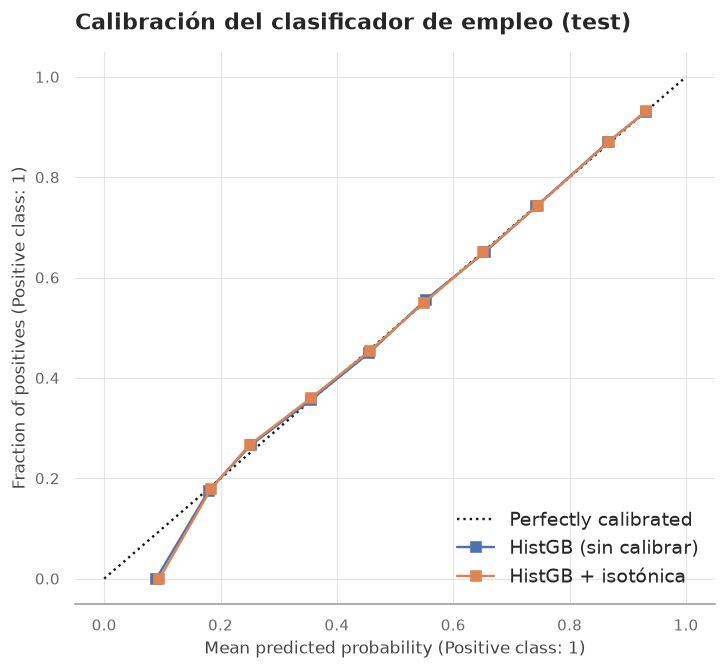

Brier score sin calibrar     : 0.1592
Brier score con isotónica    : 0.1591   (más bajo = mejor calibrado)


In [43]:
# Calibración del clasificador de empleo (Clase 6): primero MEDIR, luego CORREGIR
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

# corrección isotónica: aprende una transformación monótona de las probabilidades
from sklearn.base import clone
# se calibra el MISMO pipeline tuneado del Modelo B (clone sin entrenar)
cal_clf = CalibratedClassifierCV(clone(best_clf),
    method="isotonic", cv=3).fit(Xc_tr, yc_tr)
proba_cal = cal_clf.predict_proba(Xc_te)[:, 1]

fig, ax = plt.subplots(figsize=(6.5, 6))
CalibrationDisplay.from_predictions(yc_te, proba_te, n_bins=10, ax=ax, name="HistGB (sin calibrar)")
CalibrationDisplay.from_predictions(yc_te, proba_cal, n_bins=10, ax=ax, name="HistGB + isotónica")
ax.set_title("Calibración del clasificador de empleo (test)")
ax.grid(True, axis="both")
plt.tight_layout(); plt.savefig(FIG / "calibracion_empleo.png", dpi=150); plt.show()

brier_sin = brier_score_loss(yc_te, proba_te)
brier_cal = brier_score_loss(yc_te, proba_cal)
print(f"Brier score sin calibrar     : {brier_sin:.4f}")
print(f"Brier score con isotónica    : {brier_cal:.4f}   (más bajo = mejor calibrado)")

> 🧭 Calculo la brecha de ingreso por sexo **dentro de cada región** y las ordeno, para identificar si en algún corte la brecha es muy baja o incluso favorece a las mujeres. Por equidad analítica, busco activamente evidencia que **contradiga o matice** mi hipótesis, en lugar de reportar sólo lo que la confirma. Mostrar dónde la brecha es menor es parte de un uso honesto y no sesgado de los resultados.
>
> Reportar únicamente los cortes que refuerzan la hipótesis sería *cherry-picking*: daría una imagen sesgada y debilitaría la credibilidad de todo el trabajo.

In [44]:
# Discriminación inversa: ¿hay cortes (regiones) donde la brecha favorece a mujeres?
rows = []
for rg, d in ob.groupby("region"):
    dv, dm = d[d.sexo == "Varón"], d[d.sexo == "Mujer"]
    if len(dv) < 200 or len(dm) < 200:
        continue
    g = np.average(dv.log_ing, weights=dv.PONDIIO) - np.average(dm.log_ing, weights=dm.PONDIIO)
    rows.append((rg, 100*(np.exp(g)-1)))
inv = pd.DataFrame(rows, columns=["region","brecha_pct (V−M)"]).sort_values("brecha_pct (V−M)")
print("Brecha de ingreso Varón−Mujer por región (% en nivel):")
print(inv.round(1).to_string(index=False))
print("\n(valor menor = brecha más reducida; un valor negativo indicaría ventaja femenina)")

Brecha de ingreso Varón−Mujer por región (% en nivel):
   region  brecha_pct (V−M)
 Nordeste            37.900
 Noroeste            40.600
 Pampeana            46.600
Patagonia            47.200
      GBA            50.900
     Cuyo            52.300

(valor menor = brecha más reducida; un valor negativo indicaría ventaja femenina)


In [45]:
# --- Lectura dinámica: Brier antes/después de calibrar, de esta corrida ---
from IPython.display import Markdown
_d = round(brier_sin, 4) - round(brier_cal, 4)
_cmp = ("desciende" if _d > 0 else
        "se mantiene prácticamente igual" if _d == 0 else "no desciende")
Markdown(f"""**Lectura.** La calibración no sólo se mide: se **corrige** con regresión isotónica
(Clase 6). El *Brier score* pasa de {brier_sin:.4f} (sin calibrar) a {brier_cal:.4f}
(calibrado), es decir {_cmp}; la curva calibrada se aproxima a la diagonal, de modo que
las probabilidades del modelo admiten una **interpretación directa** (un '70 %' significa
~70 de cada 100). El análisis por región muestra que la brecha de ingreso por sexo es
**generalizada** aunque de **magnitud heterogénea**; reportarla de forma equilibrada
—incluyendo las regiones donde es menor— forma parte de un uso responsable de estos
modelos.""")


**Lectura.** La calibración no sólo se mide: se **corrige** con regresión isotónica
(Clase 6). El *Brier score* pasa de 0.1592 (sin calibrar) a 0.1591
(calibrado), es decir desciende; la curva calibrada se aproxima a la diagonal, de modo que
las probabilidades del modelo admiten una **interpretación directa** (un '70 %' significa
~70 de cada 100). El análisis por región muestra que la brecha de ingreso por sexo es
**generalizada** aunque de **magnitud heterogénea**; reportarla de forma equilibrada
—incluyendo las regiones donde es menor— forma parte de un uso responsable de estos
modelos.

## 13. Conclusiones y limitaciones

> 🧭 Cierro con las conclusiones **generadas a partir de las variables de esta misma corrida**: cada cifra del texto que sigue proviene del estado actual del notebook, no de un texto tipeado aparte. Si las escribiera a mano, cualquier re-ejecución podría dejar números y conclusiones contradiciéndose entre sí.

In [46]:
# --- Conclusiones dinámicas: todas las cifras provienen de las variables de esta corrida ---
from IPython.display import Markdown
_b  = (BRECHA_NIVEL['35-44'] + BRECHA_NIVEL['45-49']) / 2
_km, _kv = BK['Mujer']['aceleracion'], BK['Varón']['aceleracion']
_pn = 100 * no_explicado / gap
_LV, _LM = LENTES["Varón"], LENTES["Mujer"]
_coh_v, _coh_m = COHORTES["Varón"]["48→56"], COHORTES["Mujer"]["48→56"]
_cav = 100 * (caidas_alin['Varón'][0] - caidas_alin['Varón'][1])
_cam = 100 * (caidas_alin['Mujer'][0] - caidas_alin['Mujer'][1])
_dv55, _dm55 = PD.loc["55-59", "deso_Varón"], PD.loc["55-59", "deso_Mujer"]
_pgap = -PD.loc["35-44":"45-54", "brecha_part"].mean()
_cv = 100 * (caidas['Varón'][0] - caidas['Varón'][1])
_cm = 100 * (caidas['Mujer'][0] - caidas['Mujer'][1])
_clu = (f"**emerge** un cluster de mayor edad (media {perfil.loc[hi, 'edad']:.0f} años) y menor inserción "
        f"({100 * perfil.loc[hi, 'pct_ocupado']:.0f}% de empleo), que apoya la hipótesis sin imponerla"
        if emerge else
        "**no** emerge un único cluster que combine nítidamente edad alta y baja inserción; se reporta "
        "este resultado tal cual (la evidencia principal descansa en los Modelos A y B)")
Markdown(f"""**Hallazgos.**

1. La **tasa de desocupación** no capta el fenómeno: en las edades avanzadas la
   salida se dirige hacia la **inactividad**. La brecha de empleo por sexo (~{_b:.0f} pts a
   los 35–49) es, ante todo, una **brecha de participación** (~{_pgap:.0f} pts): entre
   quienes **sí participan**, la desocupación femenina es apenas mayor de joven y **se
   invierte desde los 55** (55–59: varones {_dv55:.1f}% vs. mujeres {_dm55:.1f}%) — cerca de la
   jubilación, a los varones activos les va **peor** (H1); los determinantes de oferta
   de la participación (cuidados, hogar, transferencias) no son observables (H2). La
   tasa de empleo cae en **dos fases** (estimadas, no fijadas): descenso gradual desde
   **~{onset_min} en ambos sexos** y aceleración **~{_km} en mujeres / ~{_kv} en varones**;
   alineando por la edad jubilatoria propia (60/65), ese *timing* más temprano de las
   mujeres es **mayormente institucional**, y la caída previa al retiro propio es
   **mayor en varones** (−{CAIDA_PRE['Varón']:.0f} vs. −{CAIDA_PRE['Mujer']:.0f} pts) con **igual intensidad anual**
   ({_LV['abs_anual']:.2f} vs. {_LM['abs_anual']:.2f} pts/año): la ley los expone cinco años más. El chequeo de
   **cohortes** (2016→2024) confirma que, a igual edad, la caída masculina real es igual
   o mayor (48→56: {_coh_v['cohorte']:+.1f} pts vs. {_coh_m['cohorte']:+.1f}); la curva transversal femenina está
   inflada por composición de cohortes.
2. **Modelo A (ingreso):** tras controlar por educación, región y año (R² = {r2_test:.2f} en
   test), la **edad** y el **sexo** conservan poder explicativo; el ingreso relativo
   desciende en torno a la edad jubilatoria.
3. **Modelo B (empleo):** el *partial dependence* evidencia una **penalización etaria
   neta** sobre la probabilidad de estar ocupado (ROC-AUC = {auc_te:.2f} en test) que
   afecta a **ambos sexos**. En la **ventana alineada a la jubilación propia** (varones
   40→64, mujeres 35→59) la caída es de **{_cav:.0f} pts en varones y {_cam:.0f} pts en
   mujeres**: la penalización etaria **no es menor en varones** (H1). La caída cruda
   35→64 ({_cv:.0f} y {_cm:.0f} pts) es mayor en mujeres porque esa franja las incluye ya
   jubilables (60–64): esa porción es **institucional**, no penalización.
4. **Oaxaca–Blinder:** la brecha de ingreso por sexo (~{100 * (np.exp(gap) - 1):.0f} % en nivel;
   IC 95 % bootstrap {100 * (np.exp(gap_ci[0]) - 1):.0f}–{100 * (np.exp(gap_ci[1]) - 1):.0f} %) resulta
   **no explicada** por las características observables ({_pn:.0f} % en el componente
   residual; el explicado es incluso negativo).
5. **Fairness:** el clasificador reproduce disparidades por sexo y franja etaria.
6. **Evolución temporal (2016–2024):** el componente *no explicado* de la brecha
   de ingreso permanece elevado a lo largo de casi una década y la penalización de
   empleo en la franja de mayor edad (60–64) se mantiene mayor en mujeres —franja en
   la que ellas ya alcanzaron su edad jubilatoria, por lo que parte de esa diferencia
   es **institucional**—, lo que sugiere un fenómeno **estructural** más que coyuntural
   (con 2020 como valor atípico asociado a la pandemia).
7. **SHAP:** confirma a nivel individual que una mayor edad incrementa la
   predicción de no-empleo y que dicho efecto se acelera pasada la mitad de la
   cincuentena (consistente con el quiebre estimado en 4.2); la condición de mujer
   presenta un aporte negativo y sistemático. El resultado es consistente con la
   importancia por permutación y con Oaxaca–Blinder.
8. **Clustering (no supervisado, k = {k_opt}):** segmentando **sólo por rasgos
   estructurales** (edad, nivel educativo) y perfilando con variables de resultado
   que no intervinieron en el modelo, {_clu}.

En conjunto, **cinco enfoques independientes** —análisis descriptivo, regresión,
clasificación con partial dependence, Oaxaca–Blinder y SHAP, junto con la
segmentación no supervisada— convergen en **dos resultados que conviene no mezclar**:
(i) una **penalización etaria neta** (H1) que golpea a ambos sexos —con **igual
intensidad anual**, **mayor daño acumulado en varones** (cinco años más de exposición
hasta los 65) y, siguiendo cohortes a igual edad, caída masculina igual o mayor— y
(ii) una **desventaja femenina** (H2) concentrada en la **participación** —cuya parte de
oferta vs. demanda la EPH no permite separar— y en el **castigo de ingresos entre
ocupados** (Oaxaca–Blinder), este último sí ajeno a la norma previsional. Ambos
patrones son **cuantificables y persistentes** en el período analizado.

**Limitaciones.**

- **Corte transversal / sesgo de selección:** se comparan personas de distintas
  edades en un mismo momento, sin seguimiento longitudinal; parte del "efecto edad"
  corresponde a un efecto de cohorte, que el chequeo de pseudo-cohortes de 4.2 muestra
  **grande en mujeres** (cerca de la mitad de su caída transversal) y menor en varones —
  cohorte y transversal se reportan como cotas. La población que permanece ocupada a
  los 63 años puede constituir un subgrupo no representativo (selección).
- **Colinealidad edad/distancia al retiro:** dentro de cada sexo, t = edad − (60/65);
  ningún modelo sobre un corte transversal puede separar el "reloj etario" del "reloj
  previsional". Las conclusiones se apoyan en lo que resiste a ambos lentes.
- **No respuesta de ingresos:** `P21` presenta valores faltantes no aleatorios; los
  ponderadores de ingreso atenúan, pero no eliminan, el problema.
- **Causalidad:** los modelos estiman asociación neta y no efecto causal; la
  importancia por permutación y Oaxaca–Blinder son descriptivas y no identifican
  contrafácticos.
- **Variables ausentes:** no se observan ocupación específica, antigüedad, salud ni
  informalidad previa, que podrían explicar parte del componente residual.
- **Confounder previsional:** las mujeres se jubilan cinco años antes (60 vs 65), por
  lo que su salida más temprana del empleo es en gran parte **institucional**, no
  discriminatoria; el análisis lo controla alineando por la jubilación propia
  (secciones 4.2 y 6) y por eso la evidencia etaria se apoya en la caída prejubilatoria
  y en la ventana alineada de la *partial dependence*, no en el *timing* absoluto.
- **Oferta no observada y regímenes especiales:** la base analítica no contiene
  variables de cuidados, composición del hogar ni transferencias (p. ej. AUH), de modo
  que la brecha de **participación** mezcla oferta y demanda sin poder separarlas.
  Además, los **regímenes previsionales especiales** (p. ej. docencia, con retiro por
  años de servicio frecuentemente antes de los 60, en ocupaciones feminizadas)
  implican que parte de la salida femenina previa a los 60 puede ser también
  institucional; la EPH no registra el régimen ni el sector de las personas inactivas,
  por lo que este factor sólo puede señalarse, no medirse.

**Técnicas y referencias.** Todas las técnicas centrales son material de la cátedra:
KNN, validación cruzada, tuning de hiperparámetros y ROC-AUC (Clase 2); SVM lineal y
de kernel RBF (Clase 3); árbol de decisión (Clase 4); ensambles —votación *soft*, Random
Forest y Gradient Boosting— y el *bootstrap* del IC (Clase 5); calibración medida y
**corregida** (isotónica) con Brier score (Clase 6); k-means, inercia
intra-cluster e índice de silueta (Clase 7). Técnicas complementarias no cubiertas
por el programa, con referencia en la sección 2: **Oaxaca–Blinder** (Oaxaca 1973;
Blinder 1973), **SHAP** (Lundberg & Lee, 2017) y la auditoría de **fairness**
(`fairlearn`). *Sin redes neuronales* (es otra materia).

**Reproducibilidad.** Datos: EPH 2016–2024 descargados con el paquete `pyeph`; el
notebook es autocontenido (lee `data/processed/eph_analitico.parquet` y ejecuta
todo el análisis de punta a punta).
Entorno con `uv` (`shap` en el grupo `interpret`). Todas las figuras quedan en
`reports/figures/`. Las celdas de *Lectura* y estas conclusiones se **generan
dinámicamente** a partir de las variables de la corrida: el texto no puede divergir
de los resultados. Notebook ejecutable de punta a punta con:
`ML_FIUBA_MODO=completo uv run jupyter nbconvert --to notebook --execute --inplace notebooks/entrega.ipynb`

*Ejecutado en modo {MODO.upper()}.*""")


**Hallazgos.**

1. La **tasa de desocupación** no capta el fenómeno: en las edades avanzadas la
   salida se dirige hacia la **inactividad**. La brecha de empleo por sexo (~20 pts a
   los 35–49) es, ante todo, una **brecha de participación** (~20 pts): entre
   quienes **sí participan**, la desocupación femenina es apenas mayor de joven y **se
   invierte desde los 55** (55–59: varones 5.2% vs. mujeres 4.5%) — cerca de la
   jubilación, a los varones activos les va **peor** (H1); los determinantes de oferta
   de la participación (cuidados, hogar, transferencias) no son observables (H2). La
   tasa de empleo cae en **dos fases** (estimadas, no fijadas): descenso gradual desde
   **~49 en ambos sexos** y aceleración **~56 en mujeres / ~62 en varones**;
   alineando por la edad jubilatoria propia (60/65), ese *timing* más temprano de las
   mujeres es **mayormente institucional**, y la caída previa al retiro propio es
   **mayor en varones** (−28 vs. −20 pts) con **igual intensidad anual**
   (1.16 vs. 1.17 pts/año): la ley los expone cinco años más. El chequeo de
   **cohortes** (2016→2024) confirma que, a igual edad, la caída masculina real es igual
   o mayor (48→56: -8.2 pts vs. -4.2); la curva transversal femenina está
   inflada por composición de cohortes.
2. **Modelo A (ingreso):** tras controlar por educación, región y año (R² = 0.29 en
   test), la **edad** y el **sexo** conservan poder explicativo; el ingreso relativo
   desciende en torno a la edad jubilatoria.
3. **Modelo B (empleo):** el *partial dependence* evidencia una **penalización etaria
   neta** sobre la probabilidad de estar ocupado (ROC-AUC = 0.77 en test) que
   afecta a **ambos sexos**. En la **ventana alineada a la jubilación propia** (varones
   40→64, mujeres 35→59) la caída es de **29 pts en varones y 13 pts en
   mujeres**: la penalización etaria **no es menor en varones** (H1). La caída cruda
   35→64 (28 y 40 pts) es mayor en mujeres porque esa franja las incluye ya
   jubilables (60–64): esa porción es **institucional**, no penalización.
4. **Oaxaca–Blinder:** la brecha de ingreso por sexo (~48 % en nivel;
   IC 95 % bootstrap 47–50 %) resulta
   **no explicada** por las características observables (128 % en el componente
   residual; el explicado es incluso negativo).
5. **Fairness:** el clasificador reproduce disparidades por sexo y franja etaria.
6. **Evolución temporal (2016–2024):** el componente *no explicado* de la brecha
   de ingreso permanece elevado a lo largo de casi una década y la penalización de
   empleo en la franja de mayor edad (60–64) se mantiene mayor en mujeres —franja en
   la que ellas ya alcanzaron su edad jubilatoria, por lo que parte de esa diferencia
   es **institucional**—, lo que sugiere un fenómeno **estructural** más que coyuntural
   (con 2020 como valor atípico asociado a la pandemia).
7. **SHAP:** confirma a nivel individual que una mayor edad incrementa la
   predicción de no-empleo y que dicho efecto se acelera pasada la mitad de la
   cincuentena (consistente con el quiebre estimado en 4.2); la condición de mujer
   presenta un aporte negativo y sistemático. El resultado es consistente con la
   importancia por permutación y con Oaxaca–Blinder.
8. **Clustering (no supervisado, k = 8):** segmentando **sólo por rasgos
   estructurales** (edad, nivel educativo) y perfilando con variables de resultado
   que no intervinieron en el modelo, **emerge** un cluster de mayor edad (media 59 años) y menor inserción (59% de empleo), que apoya la hipótesis sin imponerla.

En conjunto, **cinco enfoques independientes** —análisis descriptivo, regresión,
clasificación con partial dependence, Oaxaca–Blinder y SHAP, junto con la
segmentación no supervisada— convergen en **dos resultados que conviene no mezclar**:
(i) una **penalización etaria neta** (H1) que golpea a ambos sexos —con **igual
intensidad anual**, **mayor daño acumulado en varones** (cinco años más de exposición
hasta los 65) y, siguiendo cohortes a igual edad,

In [47]:
# --- Tiempo total de ejecución del notebook (cronómetro iniciado en la 1ª celda) ---
import os as _os
_elapsed = time.perf_counter() - _t0
_m, _s = divmod(int(_elapsed), 60)
print(f"Modo: {MODO.upper()}  |  núcleos lógicos disponibles: {_os.cpu_count()}")
print(f"Tiempo total de ejecución: {_m} min {_s} s ({_elapsed:.1f} s)")

Modo: COMPLETO  |  núcleos lógicos disponibles: 18
Tiempo total de ejecución: 18 min 43 s (1123.8 s)
